# Geo Snap — Land-Use Classification & Explainability from Space
### PixelPioneers | SOI × Cosmosoc Competition

This notebook is the complete, self-contained implementation for all three tasks defined in the Geo Snap problem statement:

- **Task 1A** — RGB (3-band) land-use classification on EuroSAT
- **Task 1B** — Multispectral (13-band Sentinel-2) land-use classification
- **Task 2** — Explainability and model interpretation (Grad-CAM, band importance, confusion analysis)
- **Task 3** — Bonus environmental insights via spectral index analysis (NDVI, NDWI, SWIR moisture)

The pipeline is designed for full reproducibility: fixed random seeds, deterministic evaluation transforms, and self-describing model checkpoints that bundle weights, class lists, and normalization statistics together.

## 0. Environment Setup

All dependencies are installed and imported here. Random seeds are fixed across Python, NumPy, and PyTorch to ensure results are reproducible across runs — this directly addresses the 25% reproducibility criterion in Stage 1 scoring.

In [2]:
!pip install -q tifffile

import os, io, time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms
from PIL import Image
import tifffile as tiff
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 1. Dataset Setup

Mount Google Drive and extract the dataset. This cell is idempotent — it skips extraction if the folders already exist, so re-running it on a prepared environment does not waste time.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Running outside Colab — update DATASET_ZIP_PATH / EXTRACT_DIR below.")

DATASET_ZIP_PATH = '/content/drive/MyDrive/EuroSAT_Dataset.zip'
EXTRACT_DIR = '/content/dataset'

if IN_COLAB and not os.path.exists(os.path.join(EXTRACT_DIR, 'EuroSAT')):
    print("Extracting dataset...")
    !unzip -q "{DATASET_ZIP_PATH}" -d "{EXTRACT_DIR}"
    print("Done.")
else:
    print("Dataset ready.")

CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Mounted at /content/drive
Extracting dataset...
Done.
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2. Task 1A — RGB Data Pipeline

**Augmentation strategy:** Satellite patches have no fixed orientation (no canonical "up" from orbit), so horizontal flips, vertical flips, and 90° rotations are always valid augmentations. We additionally apply mild color jitter to handle sensor variation, and random perspective/affine transforms to simulate slight view angle differences. All augmentation is applied to the **training set only** — the validation transform is deterministic.

ImageNet mean/std normalization is retained because the RGB backbone is initialized from ImageNet pretrained weights.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms_rgb = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

eval_transforms_rgb = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dir = os.path.join(EXTRACT_DIR, 'EuroSAT/train')
val_dir   = os.path.join(EXTRACT_DIR, 'EuroSAT/val')

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms_rgb)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=eval_transforms_rgb)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"RGB train: {len(train_dataset)} | val: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

RGB train: 18900 | val: 4050
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Model Architecture

Both classifiers are built on **EfficientNet-B2**, a stronger backbone than ResNet18 for this task. It achieves higher accuracy with fewer parameters through compound scaling of depth, width, and resolution.

For the 13-band multispectral model, the first convolutional layer is expanded to accept all 13 Sentinel-2 channels. The three pretrained RGB channel weights are copied directly, and the remaining 10 channels are initialized from the average of the three RGB weights — a standard, principled approach for extending pretrained conv layers rather than starting extra channels from random noise.

A Dropout layer (p=0.3) before the final linear head acts as regularization to mitigate overfitting on the limited 64×64 patch dataset.

In [5]:
BACKBONE_NAME = "efficientnet_b2"

def build_model(in_channels, num_classes, backbone=BACKBONE_NAME, pretrained=True):
    """Build an EfficientNet-B2 classifier supporting arbitrary input channel counts."""
    if backbone == "efficientnet_b2":
        weights = models.EfficientNet_B2_Weights.DEFAULT if pretrained else None
        net = models.efficientnet_b2(weights=weights)

        if in_channels != 3:
            orig = net.features[0][0]
            new_conv = nn.Conv2d(
                in_channels, orig.out_channels,
                kernel_size=orig.kernel_size, stride=orig.stride,
                padding=orig.padding, bias=False
            )
            with torch.no_grad():
                new_conv.weight[:, :3] = orig.weight
                if in_channels > 3:
                    mean_w = orig.weight.mean(dim=1, keepdim=True)
                    new_conv.weight[:, 3:] = mean_w.repeat(1, in_channels - 3, 1, 1)
            net.features[0][0] = new_conv

        in_ftrs = net.classifier[1].in_features
        net.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(in_ftrs, num_classes)
        )
    else:
        raise ValueError(f"Unknown backbone: {backbone}")

    return net

print(f"Model builder ready (backbone: {BACKBONE_NAME}).")
model_probe = build_model(3, 10)
total_params = sum(p.numel() for p in model_probe.parameters())
print(f"Total parameters: {total_params:,}")
del model_probe

Model builder ready (backbone: efficientnet_b2).
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 198MB/s]


Total parameters: 7,715,084


## 4. Training Infrastructure

The shared training loop implements several best practices:

- **AdamW with weight decay** (5e-4) — more effective regularization than vanilla Adam because weight decay is decoupled from the adaptive gradient scaling.
- **CosineAnnealingWarmRestarts scheduler** — the learning rate follows a cosine curve and periodically resets (warm restarts), which helps escape local minima and consistently outperforms ReduceLROnPlateau on vision classification tasks.
- **Label smoothing** (0.1) — softens the one-hot targets so the model learns calibrated probabilities rather than collapsing toward near-zero entropy on training examples.
- **Best checkpoint saving** — only the weights that achieved the highest validation accuracy are kept. This avoids the common mistake of submitting the last epoch rather than the best one.
- **Early stopping** (patience = 7) — training halts automatically once the model has converged, preventing wasted compute and overfitting.

In [6]:
MAX_EPOCHS = 30
PATIENCE   = 7

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                train_size, val_size, device, checkpoint_path,
                num_epochs=MAX_EPOCHS, patience=PATIENCE, model_name="model"):
    """Train model with early stopping and best-checkpoint saving."""
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())
    no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    t0 = time.time()

    for epoch in range(num_epochs):
        # Training
        model.train()
        run_loss, run_correct = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(inputs)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            run_loss += loss.item() * inputs.size(0)
            run_correct += (out.argmax(1) == labels).sum().item()

        if scheduler is not None:
            scheduler.step()

        tr_loss = run_loss / train_size
        tr_acc  = run_correct / train_size
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)

        # Validation
        model.eval()
        v_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                out = model(inputs)
                v_loss += criterion(out, labels).item() * inputs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()

        vl_loss = v_loss / val_size
        vl_acc  = v_correct / val_size
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        print(f"Ep {epoch+1:02d}/{num_epochs} | "
              f"Train: loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"Val: loss={vl_loss:.4f} acc={vl_acc:.4f}", end="")

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_wts, checkpoint_path)
            print(f"  ✓ best")
        else:
            no_improve += 1
            print(f"  (no improve {no_improve}/{patience})")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}.")
            break

    elapsed = time.time() - t0
    print(f"\n{model_name} done in {elapsed//60:.0f}m {elapsed%60:.0f}s | Best val acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, history, best_acc


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, key_tr, key_v, ylabel in zip(
        axes,
        ["train_loss", "train_acc"],
        ["val_loss",   "val_acc"],
        ["Loss", "Accuracy"]
    ):
        ax.plot(history[key_tr], label="Train", linewidth=2)
        ax.plot(history[key_v],  label="Val",   linewidth=2)
        ax.set_title(f"{title} — {ylabel}", fontsize=13)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Training infrastructure ready.")

Training infrastructure ready.


## 5. Task 1A — Train RGB Model

In [7]:
model_rgb = build_model(in_channels=3, num_classes=NUM_CLASSES).to(device)

criterion_rgb = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_rgb = optim.AdamW(model_rgb.parameters(), lr=3e-4, weight_decay=5e-4)
scheduler_rgb = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_rgb, T_0=10, T_mult=2, eta_min=1e-6
)

RGB_CKPT = '/content/best_rgb_model.pth'
print("RGB model ready for training.")

RGB model ready for training.


Ep 01/30 | Train: loss=1.0979 acc=0.7547 | Val: loss=0.7114 acc=0.9235  ✓ best
Ep 02/30 | Train: loss=0.7745 acc=0.8898 | Val: loss=0.6556 acc=0.9420  ✓ best
Ep 03/30 | Train: loss=0.7071 acc=0.9165 | Val: loss=0.6142 acc=0.9563  ✓ best
Ep 04/30 | Train: loss=0.6780 acc=0.9275 | Val: loss=0.5924 acc=0.9635  ✓ best
Ep 05/30 | Train: loss=0.6511 acc=0.9381 | Val: loss=0.5874 acc=0.9667  ✓ best
Ep 06/30 | Train: loss=0.6332 acc=0.9434 | Val: loss=0.5889 acc=0.9632  (no improve 1/7)
Ep 07/30 | Train: loss=0.6199 acc=0.9495 | Val: loss=0.5730 acc=0.9716  ✓ best
Ep 08/30 | Train: loss=0.6106 acc=0.9539 | Val: loss=0.5701 acc=0.9721  ✓ best
Ep 09/30 | Train: loss=0.5957 acc=0.9604 | Val: loss=0.5672 acc=0.9733  ✓ best
Ep 10/30 | Train: loss=0.5950 acc=0.9614 | Val: loss=0.5706 acc=0.9733  (no improve 1/7)
Ep 11/30 | Train: loss=0.6362 acc=0.9453 | Val: loss=0.6082 acc=0.9558  (no improve 2/7)
Ep 12/30 | Train: loss=0.6282 acc=0.9472 | Val: loss=0.6032 acc=0.9548  (no improve 3/7)
Ep 13/30 | T

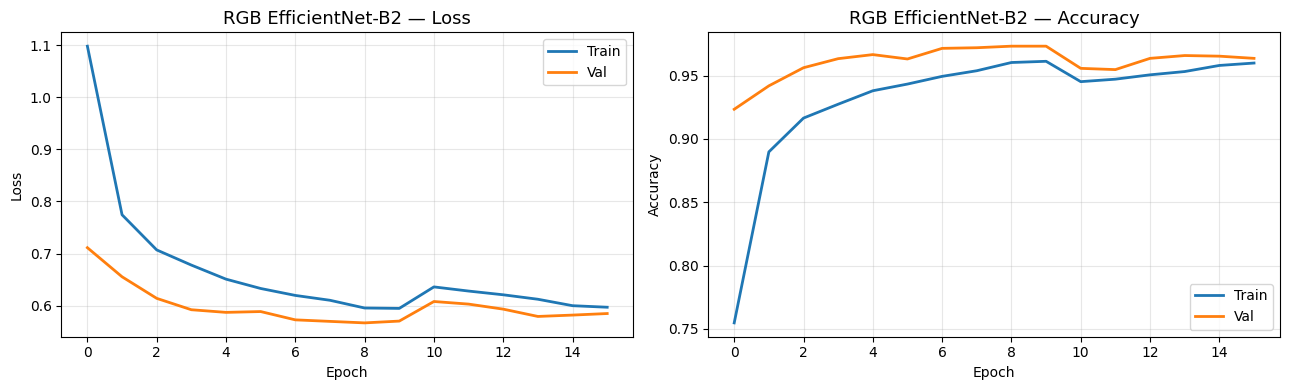

In [8]:
model_rgb, history_rgb, best_acc_rgb = train_model(
    model_rgb, train_loader, val_loader,
    criterion_rgb, optimizer_rgb, scheduler_rgb,
    train_size=len(train_dataset), val_size=len(val_dataset),
    device=device, checkpoint_path=RGB_CKPT,
    model_name="RGB EfficientNet-B2"
)
plot_history(history_rgb, "RGB EfficientNet-B2")

## 6. Save RGB Model Checkpoint

The checkpoint bundles model weights alongside the class list, architecture name, and validation accuracy. This makes the file entirely self-describing — predictions can be reproduced without referencing any external configuration.

In [9]:
rgb_save_path = '/content/drive/MyDrive/efficientnet_b2_rgb_final.pth' if IN_COLAB else './efficientnet_b2_rgb_final.pth'

torch.save({
    'model_state_dict': model_rgb.state_dict(),
    'classes': train_dataset.classes,
    'architecture': BACKBONE_NAME,
    'input_channels': 3,
    'val_accuracy': best_acc_rgb,
}, rgb_save_path)

print(f"RGB model saved → {rgb_save_path}")
print(f"Validation accuracy: {best_acc_rgb:.4f} ({best_acc_rgb*100:.2f}%)")

RGB model saved → /content/drive/MyDrive/efficientnet_b2_rgb_final.pth
Validation accuracy: 0.9733 (97.33%)


## 7. Task 1B — Multispectral (13-Band) Data Pipeline

**Normalization approach:** Per-band mean and standard deviation are computed from a representative sample of the training set and applied consistently to train, validation, and test data. This is analogous to ImageNet normalization for RGB models, but derived from the EuroSAT multispectral training distribution.

Critically, normalization statistics are computed from the **training set only** — using validation or test data to compute these statistics would constitute data leakage and would inflate reported accuracy.

**Augmentation:** The same orientation-invariant transforms used for RGB (flips, 90° rotations) are applied to the multispectral training set, since satellite patches have no canonical orientation.

In [10]:
class EuroSAT13BandDataset(Dataset):
    """Dataset for 13-band Sentinel-2 GeoTIFF images from EuroSAT."""

    def __init__(self, root_dir, band_mean=None, band_std=None, augment=False):
        self.root_dir  = root_dir
        self.band_mean = band_mean
        self.band_std  = band_std
        self.augment   = augment

        self.classes      = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.paths, self.labels = [], []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if fname.endswith('.tif'):
                    self.paths.append(os.path.join(cls_path, fname))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.paths)

    def _load_raw(self, idx):
        img = tiff.imread(self.paths[idx]).astype(np.float32)
        return torch.from_numpy(img).permute(2, 0, 1) if img.ndim == 3 else torch.from_numpy(img).unsqueeze(0)

    def __getitem__(self, idx):
        img = self._load_raw(idx)

        if self.band_mean is not None:
            img = (img - self.band_mean.view(-1, 1, 1)) / (self.band_std.view(-1, 1, 1) + 1e-6)
        else:
            for c in range(img.shape[0]):
                mn, mx = img[c].min(), img[c].max()
                if mx > mn:
                    img[c] = (img[c] - mn) / (mx - mn)

        if self.augment:
            if random.random() < 0.5:
                img = torch.flip(img, [2])
            if random.random() < 0.5:
                img = torch.flip(img, [1])
            k = random.randint(0, 3)
            if k:
                img = torch.rot90(img, k, [1, 2])
            # Spectral jitter: small random scale per band to simulate sensor noise
            if random.random() < 0.3:
                noise = 1.0 + torch.randn(img.shape[0], 1, 1) * 0.05
                img = img * noise

        return img, self.labels[idx]


def compute_band_stats(dataset, n_samples=2000, n_bands=13):
    """Estimate per-band mean and standard deviation from a training set sample."""
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    total, total_sq, pixels = (torch.zeros(n_bands, dtype=torch.float64) for _ in range(3))
    pix_count = 0
    for i in idxs:
        img = dataset._load_raw(int(i))
        c, h, w = img.shape
        total    += img.sum(dim=(1, 2)).double()
        total_sq += (img.double() ** 2).sum(dim=(1, 2))
        pix_count += h * w

    mean = (total / pix_count).float()
    var  = (total_sq / pix_count) - (total / pix_count) ** 2
    std  = var.clamp(min=1e-8).sqrt().float()
    return mean, std


train_dir_ms = os.path.join(EXTRACT_DIR, 'EuroSATallBands/train')
val_dir_ms   = os.path.join(EXTRACT_DIR, 'EuroSATallBands/val')

_raw_train = EuroSAT13BandDataset(train_dir_ms)
band_mean, band_std = compute_band_stats(_raw_train, n_samples=2000)
del _raw_train

print("Per-band mean:", [f"{v:.2f}" for v in band_mean.tolist()])
print("Per-band std :", [f"{v:.2f}" for v in band_std.tolist()])

train_dataset_ms = EuroSAT13BandDataset(train_dir_ms, band_mean, band_std, augment=True)
val_dataset_ms   = EuroSAT13BandDataset(val_dir_ms,   band_mean, band_std, augment=False)

train_loader_ms = DataLoader(train_dataset_ms, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_ms   = DataLoader(val_dataset_ms,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n13-Band pipeline ready | Train: {len(train_dataset_ms)} | Val: {len(val_dataset_ms)}")

Per-band mean: ['1353.88', '1114.88', '1036.21', '935.31', '1189.28', '1992.77', '2362.72', '2291.32', '740.16', '12.17', '1793.25', '1099.01', '2585.06']
Per-band std : ['245.68', '335.03', '397.11', '589.91', '563.89', '876.96', '1110.12', '1141.51', '415.89', '4.40', '993.80', '749.07', '1255.74']

13-Band pipeline ready | Train: 18900 | Val: 4050


## 8. Task 1B — Train Multispectral Model

In [11]:
model_ms = build_model(in_channels=13, num_classes=NUM_CLASSES).to(device)

criterion_ms = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_ms = optim.AdamW(model_ms.parameters(), lr=3e-4, weight_decay=5e-4)
scheduler_ms = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ms, T_0=10, T_mult=2, eta_min=1e-6
)

MS_CKPT = '/content/best_ms_model.pth'
print("13-Band model ready for training.")

13-Band model ready for training.


Ep 01/30 | Train: loss=0.9186 acc=0.8401 | Val: loss=0.6087 acc=0.9612  ✓ best
Ep 02/30 | Train: loss=0.6292 acc=0.9540 | Val: loss=0.5673 acc=0.9751  ✓ best
Ep 03/30 | Train: loss=0.5852 acc=0.9681 | Val: loss=0.5613 acc=0.9770  ✓ best
Ep 04/30 | Train: loss=0.5663 acc=0.9760 | Val: loss=0.5480 acc=0.9817  ✓ best
Ep 05/30 | Train: loss=0.5523 acc=0.9800 | Val: loss=0.5424 acc=0.9827  ✓ best
Ep 06/30 | Train: loss=0.5411 acc=0.9853 | Val: loss=0.5428 acc=0.9825  (no improve 1/7)
Ep 07/30 | Train: loss=0.5334 acc=0.9880 | Val: loss=0.5393 acc=0.9847  ✓ best
Ep 08/30 | Train: loss=0.5263 acc=0.9914 | Val: loss=0.5342 acc=0.9864  ✓ best
Ep 09/30 | Train: loss=0.5261 acc=0.9914 | Val: loss=0.5335 acc=0.9879  ✓ best
Ep 10/30 | Train: loss=0.5198 acc=0.9942 | Val: loss=0.5326 acc=0.9872  (no improve 1/7)
Ep 11/30 | Train: loss=0.5472 acc=0.9839 | Val: loss=0.5572 acc=0.9785  (no improve 2/7)
Ep 12/30 | Train: loss=0.5471 acc=0.9835 | Val: loss=0.5504 acc=0.9800  (no improve 3/7)
Ep 13/30 | T

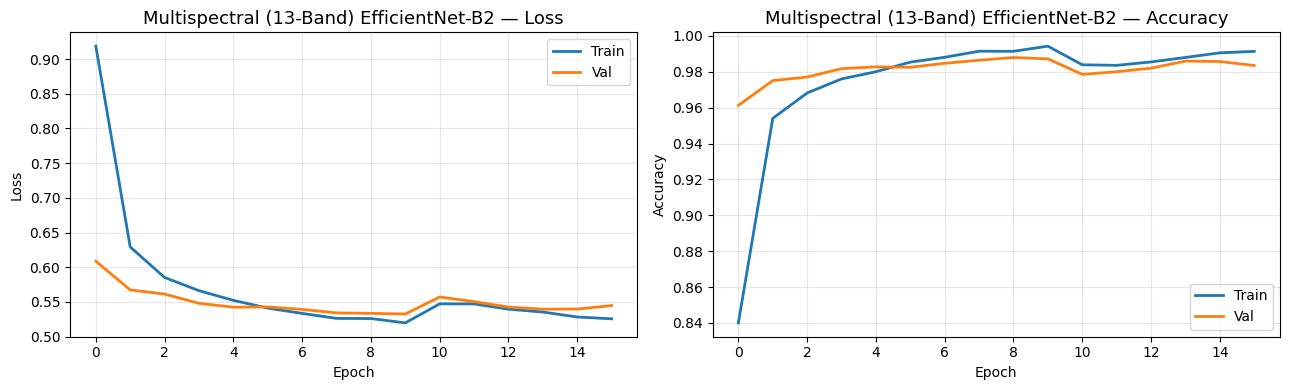

In [12]:
model_ms, history_ms, best_acc_ms = train_model(
    model_ms, train_loader_ms, val_loader_ms,
    criterion_ms, optimizer_ms, scheduler_ms,
    train_size=len(train_dataset_ms), val_size=len(val_dataset_ms),
    device=device, checkpoint_path=MS_CKPT,
    model_name="Multispectral EfficientNet-B2"
)
plot_history(history_ms, "Multispectral (13-Band) EfficientNet-B2")

## 9. Save Multispectral Model Checkpoint

The multispectral checkpoint also stores the band normalization statistics (`band_mean`, `band_std`). Without these, it would be impossible to preprocess a new test image correctly — the normalization is specific to the EuroSAT training distribution, not a fixed constant.

In [13]:
ms_save_path = '/content/drive/MyDrive/efficientnet_b2_ms_final.pth' if IN_COLAB else './efficientnet_b2_ms_final.pth'

torch.save({
    'model_state_dict': model_ms.state_dict(),
    'classes': train_dataset_ms.classes,
    'architecture': BACKBONE_NAME,
    'input_channels': 13,
    'band_mean': band_mean,
    'band_std': band_std,
    'val_accuracy': best_acc_ms,
}, ms_save_path)

print(f"Multispectral model saved → {ms_save_path}")
print(f"Validation accuracy: {best_acc_ms:.4f} ({best_acc_ms*100:.2f}%)")

Multispectral model saved → /content/drive/MyDrive/efficientnet_b2_ms_final.pth
Validation accuracy: 0.9879 (98.79%)


## 10. Task 1 Deliverables — Submission CSVs

Prediction files are generated in the exact format required by the Geo Snap rulebook:

| File | Required columns |
|------|-----------------|
| `rgb_predictions.csv` | `img_id`, `predicted_label` |
| `ms_predictions.csv` | `img_id`, `predicted_label` |

Additionally, `*_proba.csv` files with full per-class softmax probabilities are saved as intermediate outputs for the Task 2 explainability analysis (used to identify low-confidence and misclassified examples).

In [14]:
def predict_rgb_folder(model, folder, transform, class_names, device):
    model.eval()
    rows, proba_rows = [], []
    files = sorted(f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    with torch.no_grad():
        for fname in files:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            x = transform(img).unsqueeze(0).to(device)
            probs = F.softmax(model(x), dim=1)[0]
            pred = torch.argmax(probs).item()
            rows.append({'img_id': fname, 'predicted_label': class_names[pred]})
            proba_rows.append({'img_id': fname, 'predicted_label': class_names[pred],
                               **{c: probs[i].item() for i, c in enumerate(class_names)}})
    return pd.DataFrame(rows), pd.DataFrame(proba_rows)


def predict_ms_folder(model, folder, band_mean, band_std, class_names, device):
    model.eval()
    rows, proba_rows = [], []
    files = sorted(f for f in os.listdir(folder) if f.endswith('.tif'))
    with torch.no_grad():
        for fname in files:
            img = tiff.imread(os.path.join(folder, fname)).astype(np.float32)
            img = torch.from_numpy(img).permute(2, 0, 1) if img.ndim == 3 else torch.from_numpy(img).unsqueeze(0)
            img = (img - band_mean.view(-1, 1, 1)) / (band_std.view(-1, 1, 1) + 1e-6)
            x = img.unsqueeze(0).to(device)
            probs = F.softmax(model(x), dim=1)[0]
            pred = torch.argmax(probs).item()
            rows.append({'img_id': fname, 'predicted_label': class_names[pred]})
            proba_rows.append({'img_id': fname, 'predicted_label': class_names[pred],
                               **{c: probs[i].item() for i, c in enumerate(class_names)}})
    return pd.DataFrame(rows), pd.DataFrame(proba_rows)


rgb_test_dir = os.path.join(EXTRACT_DIR, 'EuroSAT_test_flat')
ms_test_dir  = os.path.join(EXTRACT_DIR, 'EuroSATallBands_test_flat')

rgb_preds_df, rgb_proba_df = predict_rgb_folder(model_rgb, rgb_test_dir, eval_transforms_rgb, train_dataset.classes, device)
ms_preds_df,  ms_proba_df  = predict_ms_folder(model_ms,  ms_test_dir,  band_mean, band_std, train_dataset_ms.classes, device)

for fname, df in [('rgb_predictions.csv', rgb_preds_df), ('ms_predictions.csv', ms_preds_df),
                  ('rgb_predictions_proba.csv', rgb_proba_df), ('ms_predictions_proba.csv', ms_proba_df)]:
    df.to_csv(fname, index=False)
    if IN_COLAB:
        os.system(f"cp {fname} /content/drive/MyDrive/")

print(f"rgb_predictions.csv: {len(rgb_preds_df)} rows")
print(f"ms_predictions.csv:  {len(ms_preds_df)} rows")
print("\nRGB class distribution:")
print(rgb_preds_df['predicted_label'].value_counts().to_string())
print("\nMultispectral class distribution:")
print(ms_preds_df['predicted_label'].value_counts().to_string())

rgb_predictions.csv: 4050 rows
ms_predictions.csv:  4050 rows

RGB class distribution:
predicted_label
AnnualCrop              474
SeaLake                 448
HerbaceousVegetation    447
Forest                  442
Residential             437
Industrial              383
PermanentCrop           380
River                   373
Highway                 372
Pasture                 294

Multispectral class distribution:
predicted_label
AnnualCrop              454
Residential             452
SeaLake                 451
Forest                  450
HerbaceousVegetation    447
Highway                 377
PermanentCrop           375
Industrial              371
River                   370
Pasture                 303


## 11. Task 2A — Validation Set Confusion Matrix & Error Analysis

**Error and confusion analysis** is a core requirement of Task 2C. The confusion matrix reveals which class pairs are most often confused and guides spectral and visual reasoning about why those confusions occur.

Classes that are visually similar in RGB — such as AnnualCrop vs. PermanentCrop, or Pasture vs. HerbaceousVegetation — are expected confusion pairs. The multispectral model should resolve many of these through spectral signatures that RGB cannot capture.

In [15]:
def evaluate_model_full(model, loader, class_names, device, is_ms=False, band_mean=None, band_std=None):
    """Run inference over the entire validation set and collect true/predicted labels with probabilities."""
    model.eval()
    all_preds, all_true, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            out   = model(inputs)
            probs = F.softmax(out, dim=1)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_true.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
    return all_true, all_preds, all_probs


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        [f'{title} — Counts', f'{title} — Normalized']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax,
                    linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('True', fontsize=12)
        ax.set_title(ttl, fontsize=13)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.show()
    return cm, cm_norm


# Evaluate both models on the validation set
true_rgb,  pred_rgb,  proba_rgb  = evaluate_model_full(model_rgb, val_loader, train_dataset.classes, device)
true_ms,   pred_ms,   proba_ms   = evaluate_model_full(model_ms,  val_loader_ms, train_dataset_ms.classes, device)

print(f"RGB Model — Validation Accuracy: {sum(t==p for t,p in zip(true_rgb,pred_rgb))/len(true_rgb):.4f}")
print(f"MS  Model — Validation Accuracy: {sum(t==p for t,p in zip(true_ms, pred_ms ))/len(true_ms ):.4f}")

RGB Model — Validation Accuracy: 0.9733
MS  Model — Validation Accuracy: 0.9879


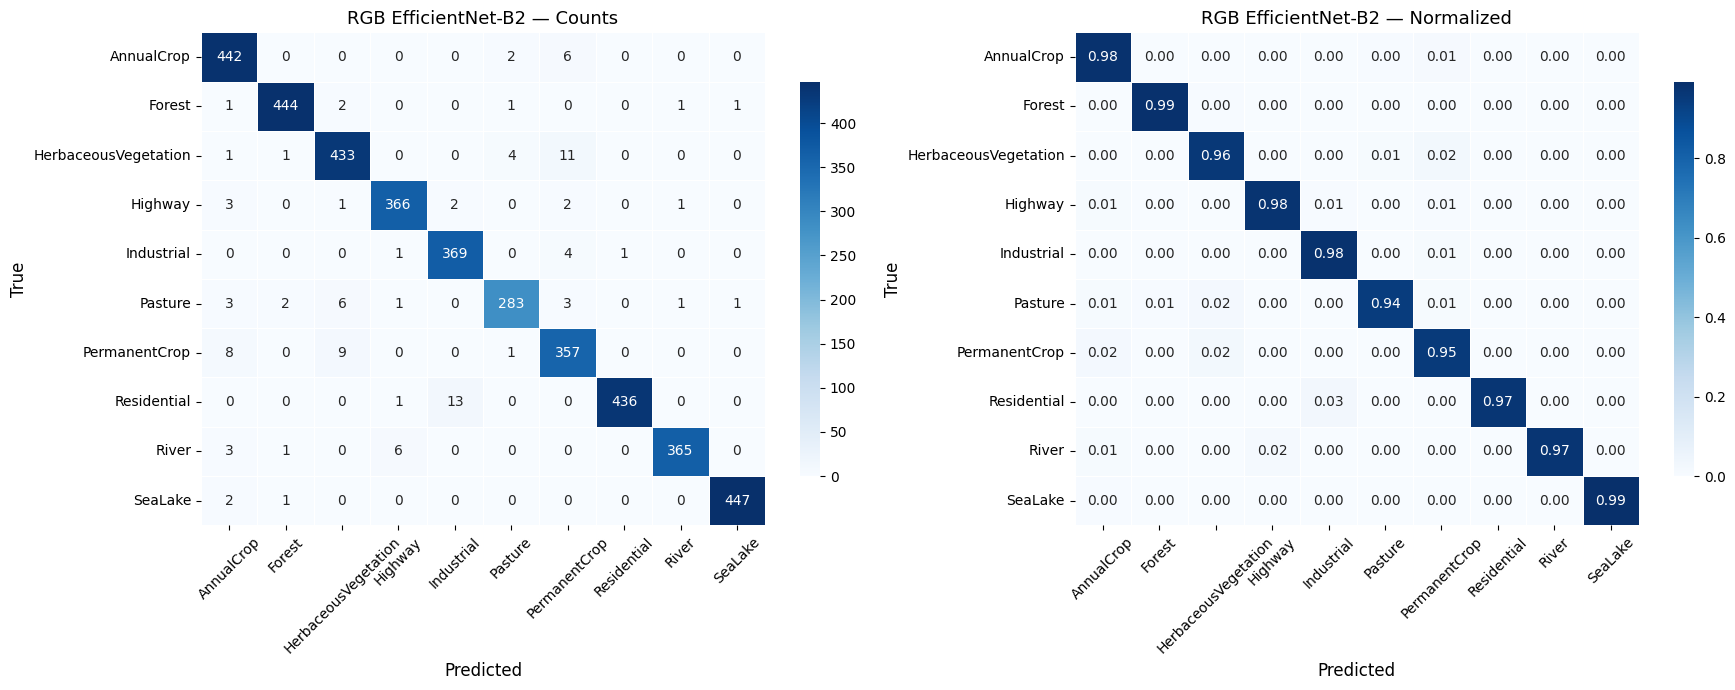

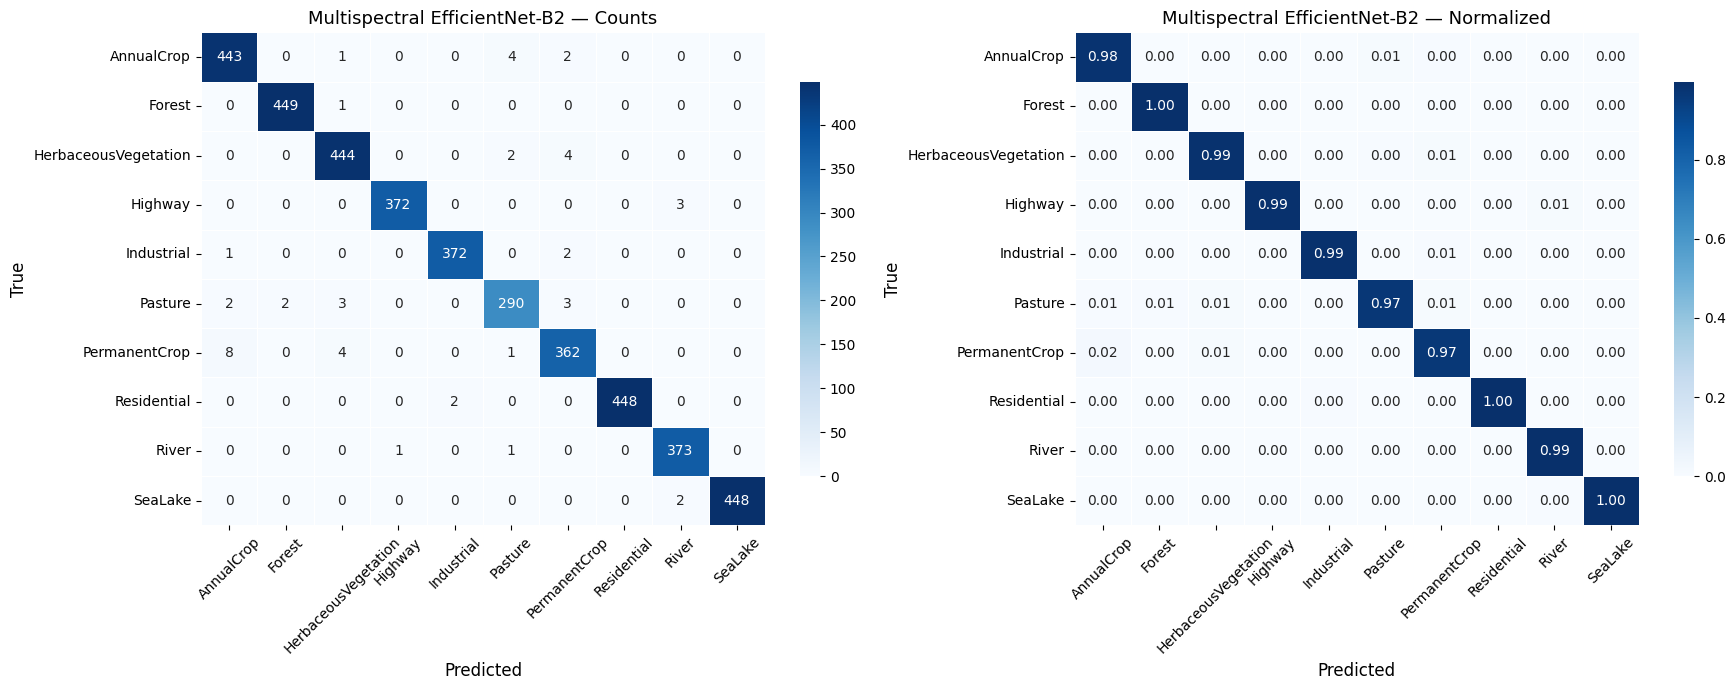

In [16]:
cm_rgb, cm_rgb_norm = plot_confusion_matrix(true_rgb, pred_rgb, train_dataset.classes, "RGB EfficientNet-B2")
cm_ms,  cm_ms_norm  = plot_confusion_matrix(true_ms,  pred_ms,  train_dataset_ms.classes, "Multispectral EfficientNet-B2")

In [17]:
print("=" * 60)
print("RGB Model — Per-Class Classification Report")
print("=" * 60)
print(classification_report(true_rgb, pred_rgb, target_names=train_dataset.classes))

print("=" * 60)
print("Multispectral Model — Per-Class Classification Report")
print("=" * 60)
print(classification_report(true_ms, pred_ms, target_names=train_dataset_ms.classes))

RGB Model — Per-Class Classification Report
                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.98      0.97       450
              Forest       0.99      0.99      0.99       450
HerbaceousVegetation       0.96      0.96      0.96       450
             Highway       0.98      0.98      0.98       375
          Industrial       0.96      0.98      0.97       375
             Pasture       0.97      0.94      0.96       300
       PermanentCrop       0.93      0.95      0.94       375
         Residential       1.00      0.97      0.98       450
               River       0.99      0.97      0.98       375
             SeaLake       1.00      0.99      0.99       450

            accuracy                           0.97      4050
           macro avg       0.97      0.97      0.97      4050
        weighted avg       0.97      0.97      0.97      4050

Multispectral Model — Per-Class Classification Report
                      precision

## 12. Task 2A — Grad-CAM Visual Explainability

**Grad-CAM (Gradient-weighted Class Activation Mapping)** highlights which spatial regions of an input image most influenced the model's prediction. For each image, the gradient of the predicted class score with respect to the final convolutional feature map is computed, then projected back onto the input resolution.

Examining Grad-CAM outputs for both correct and incorrect predictions reveals whether the model is attending to semantically meaningful regions (e.g., field texture for AnnualCrop) or spurious patterns. This is a Task 2A requirement.

In [18]:
class GradCAM:
    """Grad-CAM implementation targeting EfficientNet-B2's final feature block."""

    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients   = None

        # EfficientNet-B2: hook the last convolutional block
        target = model.features[-1]

        def fwd(m, inp, out):
            self.activations = out.detach()

        def bwd(m, gin, gout):
            self.gradients = gout[0].detach()

        target.register_forward_hook(fwd)
        target.register_full_backward_hook(bwd)

    def generate(self, input_tensor, class_idx=None):
        """Return (heatmap [H,W], predicted class index)."""
        self.model.eval()
        inp = input_tensor.unsqueeze(0).to(next(self.model.parameters()).device)
        inp.requires_grad_()

        out = self.model(inp)
        target_cls = class_idx if class_idx is not None else out.argmax(1).item()

        self.model.zero_grad()
        out[0, target_cls].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam = cam / (cam.max() + 1e-8)

        import torch.nn.functional as TF
        cam = TF.interpolate(cam.unsqueeze(0).unsqueeze(0),
                              size=input_tensor.shape[-2:],
                              mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), target_cls


def show_gradcam_grid(model, dataset, class_names, device, modality='rgb', n_examples=10):
    """Display a grid of Grad-CAM overlays covering correct and incorrect predictions."""
    cam_engine = GradCAM(model)
    results = {'correct': [], 'incorrect': []}

    for idx in np.random.choice(len(dataset), size=min(500, len(dataset)), replace=False):
        img_t, true_lbl = dataset[idx]
        heatmap, pred_lbl = cam_engine.generate(img_t)

        entry = {'img': img_t, 'heatmap': heatmap, 'true': true_lbl, 'pred': pred_lbl}
        key   = 'correct' if pred_lbl == true_lbl else 'incorrect'
        if len(results[key]) < n_examples // 2:
            results[key].append(entry)

        if len(results['correct']) >= n_examples // 2 and len(results['incorrect']) >= n_examples // 2:
            break

    all_results = results['correct'] + results['incorrect']
    n = len(all_results)
    fig, axes = plt.subplots(3, n, figsize=(n * 2.8, 8))

    for col, entry in enumerate(all_results):
        img_t   = entry['img']
        heatmap = entry['heatmap']
        true_l  = class_names[entry['true']]
        pred_l  = class_names[entry['pred']]
        correct = entry['true'] == entry['pred']

        # Convert to displayable RGB
        if modality == 'rgb':
            mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
            std  = np.array(IMAGENET_STD ).reshape(3,1,1)
            rgb  = (img_t[:3].numpy() * std + mean).transpose(1,2,0).clip(0,1)
        else:
            # Sentinel-2 true colour: B4=idx3, B3=idx2, B2=idx1
            ch = img_t[[3,2,1]].numpy()
            lo, hi = np.percentile(ch, (2, 98))
            rgb = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1).transpose(1,2,0)

        # Row 0: original image
        axes[0, col].imshow(rgb)
        axes[0, col].set_title(f"True: {true_l}", fontsize=8, color='green' if correct else 'red')
        axes[0, col].axis('off')

        # Row 1: heatmap
        axes[1, col].imshow(heatmap, cmap='jet')
        axes[1, col].set_title(f"Pred: {pred_l}", fontsize=8, color='green' if correct else 'red')
        axes[1, col].axis('off')

        # Row 2: overlay
        axes[2, col].imshow(rgb)
        axes[2, col].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[2, col].set_title('Overlay', fontsize=8)
        axes[2, col].axis('off')

    plt.suptitle(f"Grad-CAM — {modality.upper()} Model  |  Left half: Correct   Right half: Incorrect",
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print("Grad-CAM engine ready.")

Grad-CAM engine ready.


Generating Grad-CAM grid — RGB model...


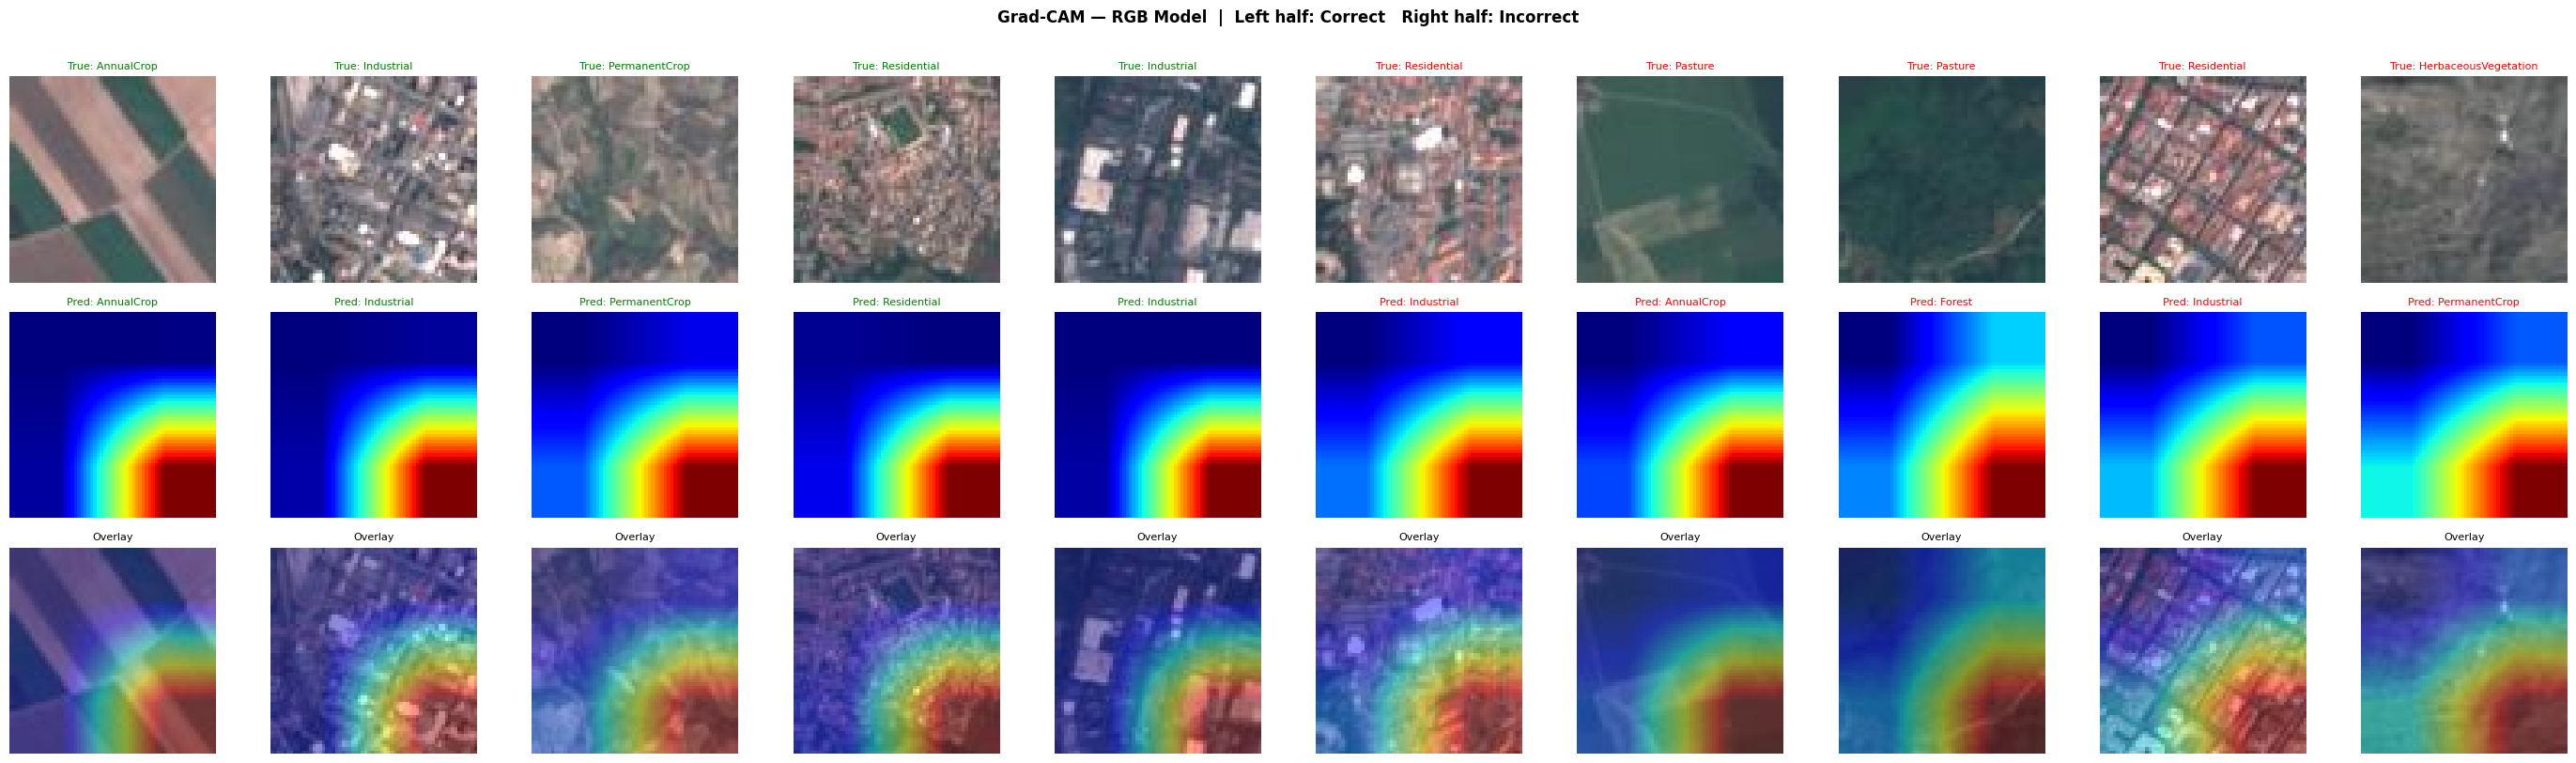


Generating Grad-CAM grid — Multispectral model...


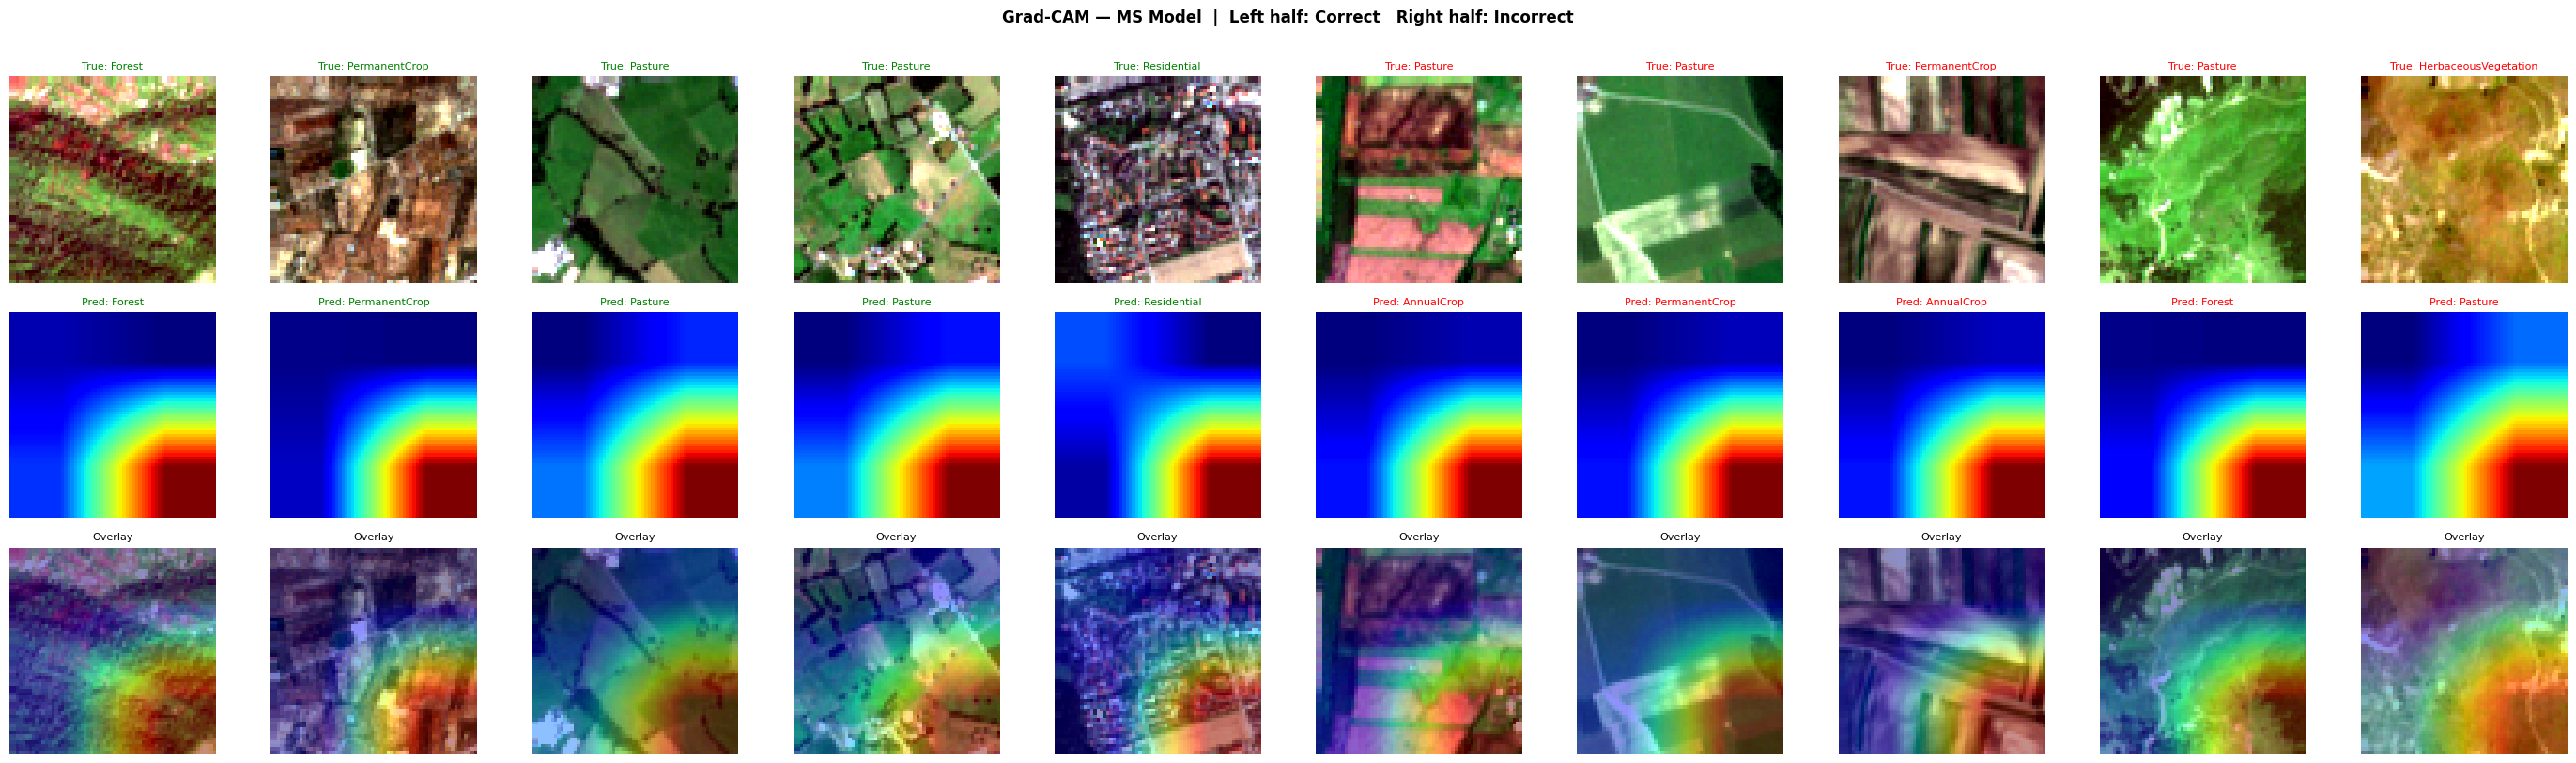

In [19]:
print("Generating Grad-CAM grid — RGB model...")
show_gradcam_grid(model_rgb, val_dataset, train_dataset.classes, device, modality='rgb', n_examples=10)

print("\nGenerating Grad-CAM grid — Multispectral model...")
show_gradcam_grid(model_ms, val_dataset_ms, train_dataset_ms.classes, device, modality='ms', n_examples=10)

## 13. Task 2B — Spectral Band Importance Analysis

**Band importance** is assessed by measuring how much each individual Sentinel-2 band contributes to the multispectral model's accuracy. For each band, the channel is zeroed out (replaced with its mean value) and the resulting accuracy drop is recorded — bands with large accuracy drops are the most informative for classification.

This analysis connects the model's learned representations to established remote sensing principles: NIR and Red Edge bands are known to be critical for vegetation discrimination, while SWIR bands are important for urban and moisture-related classes.

Running band occlusion importance analysis...
  Band  0 (  B1): accuracy drop = +0.0325
  Band  1 (  B2): accuracy drop = +0.2113
  Band  2 (  B3): accuracy drop = +0.1063
  Band  3 (  B4): accuracy drop = +0.0050
  Band  4 (  B5): accuracy drop = -0.0012
  Band  5 (  B6): accuracy drop = -0.0012
  Band  6 (  B7): accuracy drop = -0.0025
  Band  7 (  B8): accuracy drop = +0.0150
  Band  8 ( B8A): accuracy drop = +0.0100
  Band  9 (  B9): accuracy drop = +0.0025
  Band 10 ( B10): accuracy drop = +0.0000
  Band 11 ( B11): accuracy drop = +0.0012
  Band 12 ( B12): accuracy drop = -0.0025


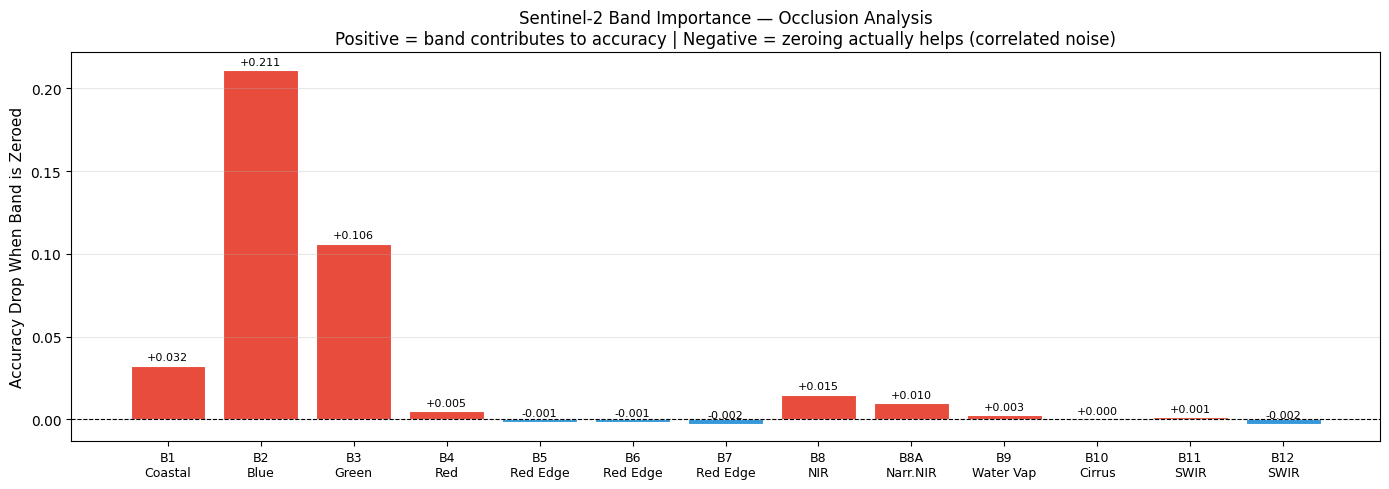


Baseline multispectral accuracy: 0.9888


In [22]:
def band_occlusion_importance(model, val_dataset_ms, band_mean, band_std, class_names, device, n_samples=800):
    """
    Compute per-band importance by zeroing each band and measuring accuracy drop.
    A larger accuracy drop means the band carries more discriminative information.
    """
    BAND_LABELS = [
        'B1\nCoastal', 'B2\nBlue', 'B3\nGreen', 'B4\nRed',
        'B5\nRed Edge', 'B6\nRed Edge', 'B7\nRed Edge', 'B8\nNIR',
        'B8A\nNarr.NIR', 'B9\nWater Vap', 'B10\nCirrus', 'B11\nSWIR', 'B12\nSWIR'
    ]

    idxs = np.random.default_rng(SEED).choice(len(val_dataset_ms),
                                               size=min(n_samples, len(val_dataset_ms)), replace=False)

    # Baseline accuracy
    model.eval()
    correct_base = 0
    all_imgs, all_labels = [], []
    for i in idxs:
        img, lbl = val_dataset_ms[int(i)]
        all_imgs.append(img)
        all_labels.append(lbl)

    batch_size = 64
    with torch.no_grad():
        for b in range(0, len(all_imgs), batch_size):
            imgs   = torch.stack(all_imgs[b:b+batch_size]).to(device)
            labels = torch.tensor(all_labels[b:b+batch_size]).to(device)
            out    = model(imgs)
            correct_base += (out.argmax(1) == labels).sum().item()

    baseline_acc = correct_base / len(all_imgs)

    # Per-band accuracy after occlusion
    band_acc_drops = []
    for band_idx in range(13):
        correct_occluded = 0
        for b in range(0, len(all_imgs), batch_size):
            imgs   = torch.stack(all_imgs[b:b+batch_size]).clone().to(device)
            labels = torch.tensor(all_labels[b:b+batch_size]).to(device)
            imgs[:, band_idx, :, :] = 0.0   # Zero out the band (equivalent to setting to mean after normalization)
            with torch.no_grad():
                out = model(imgs)
            correct_occluded += (out.argmax(1) == labels).sum().item()
        drop = baseline_acc - correct_occluded / len(all_imgs)
        band_acc_drops.append(drop)
        print(f"  Band {band_idx:2d} ({BAND_LABELS[band_idx].split(chr(10))[0]:>4s}): "
              f"accuracy drop = {drop:+.4f}")

    # Plot
    colors = ['#e74c3c' if d > 0 else '#3498db' for d in band_acc_drops]
    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(13), band_acc_drops, color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(13))
    ax.set_xticklabels(BAND_LABELS, fontsize=9)
    ax.set_ylabel("Accuracy Drop When Band is Zeroed", fontsize=11)
    ax.set_title("Sentinel-2 Band Importance — Occlusion Analysis\n"
                 "Positive = band contributes to accuracy | Negative = zeroing actually helps (correlated noise)",
                 fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, band_acc_drops):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:+.3f}", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    return band_acc_drops, BAND_LABELS, baseline_acc


print("Running band occlusion importance analysis...")
band_drops, band_labels, baseline_acc_ms = band_occlusion_importance(
    model_ms, val_dataset_ms, band_mean, band_std, train_dataset_ms.classes, device
)
print(f"\nBaseline multispectral accuracy: {baseline_acc_ms:.4f}")

## 14. Task 2B — Per-Class Band Activation Profiles

Beyond global band importance, we examine which spectral bands are activated most strongly for each land-use class. This connects model behavior to known spectral signatures — for example, vegetation classes (Forest, HerbaceousVegetation, Pasture) should show high activation in NIR and Red Edge bands, while water bodies (SeaLake, River) should show elevated response in SWIR bands.

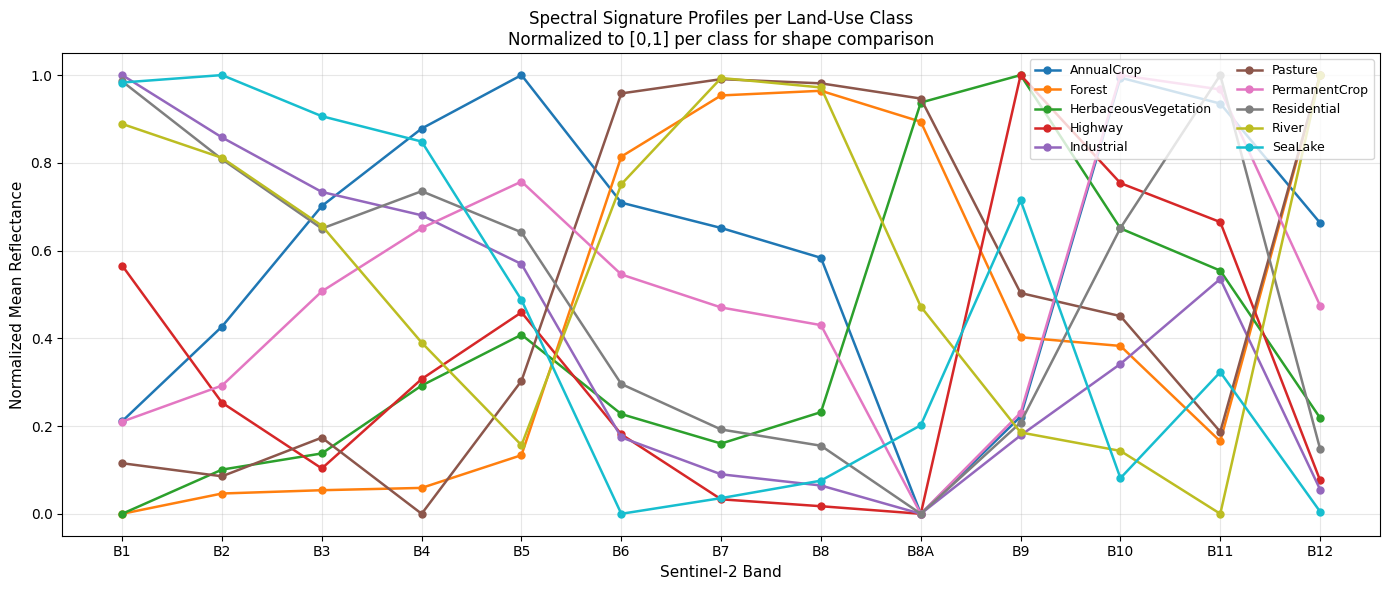

In [24]:
def compute_class_band_profiles(val_dataset_ms, class_names, n_samples=500):
    """
    Compute mean normalized band values per class from raw (un-normalized) images.
    """
    BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11','B12']
    profiles = {cls: [] for cls in class_names}

    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(val_dataset_ms), size=min(n_samples, len(val_dataset_ms)), replace=False)

    for i in idxs:
        img, lbl = val_dataset_ms[int(i)]
        cls = class_names[lbl]
        band_means = img.mean(dim=(1,2)).numpy()
        profiles[cls].append(band_means)

    fig, ax = plt.subplots(figsize=(14, 6))
    cmap = plt.get_cmap('tab10')
    for k, cls in enumerate(class_names):
        if profiles[cls]:
            arr = np.array(profiles[cls])
            mu  = arr.mean(axis=0)
            mu_norm = (mu - mu.min()) / (mu.max() - mu.min() + 1e-8)
            ax.plot(range(13), mu_norm, marker='o', label=cls,
                    color=cmap(k), linewidth=1.8, markersize=5)

    ax.set_xticks(range(13))
    ax.set_xticklabels(BAND_NAMES, fontsize=10)
    ax.set_xlabel("Sentinel-2 Band", fontsize=11)
    ax.set_ylabel("Normalized Mean Reflectance", fontsize=11)
    ax.set_title("Spectral Signature Profiles per Land-Use Class\n"
                 "Normalized to [0,1] per class for shape comparison", fontsize=12)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return profiles


class_profiles = compute_class_band_profiles(val_dataset_ms, train_dataset_ms.classes)

## 15. Task 2C — Misclassification Deep Dive

The most instructive errors are those where the model is confidently wrong. We identify the highest-confidence misclassifications on the validation set and display their Grad-CAM overlays alongside the true and predicted class labels.

For each confusion pair, we also explain the spectral basis for the error — this addresses the Task 2C requirement to provide *spectral and/or visual reasoning* for why certain classes are confused.


Analyzing RGB model misclassifications...


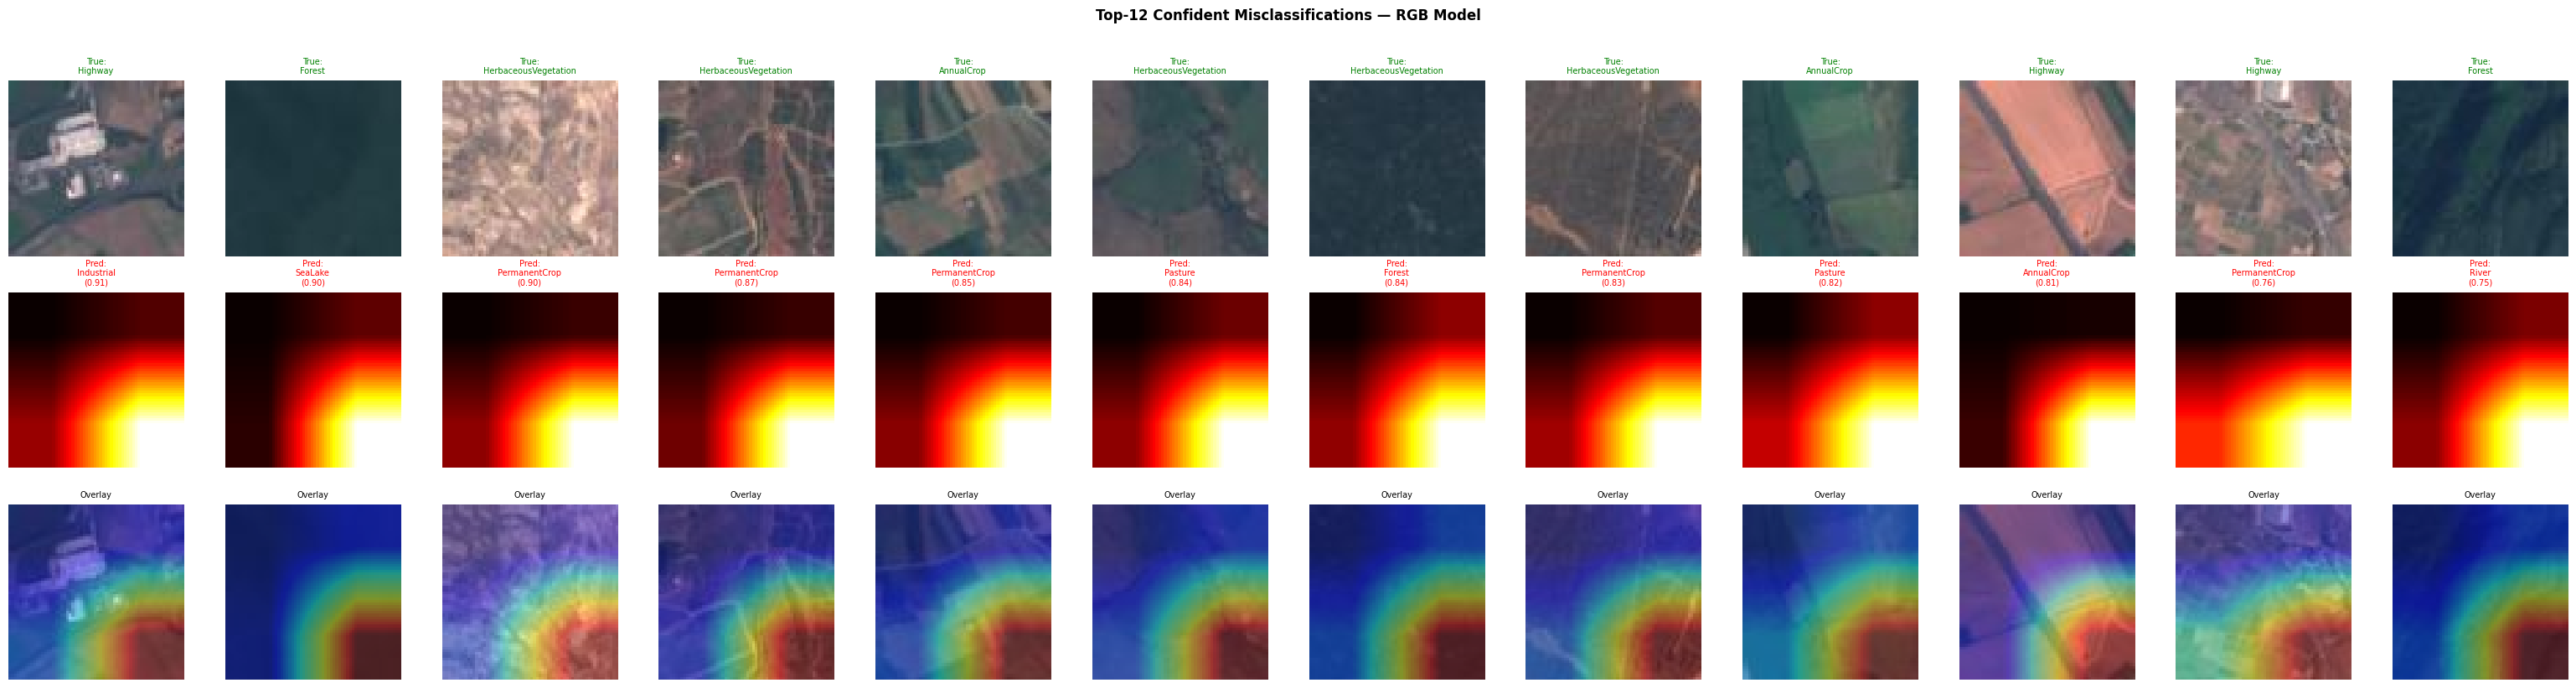


Top confusion pairs (true → predicted):
  HerbaceousVegetation      → PermanentCrop             : 11 times
  AnnualCrop                → PermanentCrop             : 6 times
  HerbaceousVegetation      → Pasture                   : 4 times
  Highway                   → AnnualCrop                : 3 times
  Industrial                → PermanentCrop             : 3 times
  Highway                   → Industrial                : 2 times
  AnnualCrop                → Pasture                   : 2 times
  Highway                   → PermanentCrop             : 2 times

Analyzing Multispectral model misclassifications...


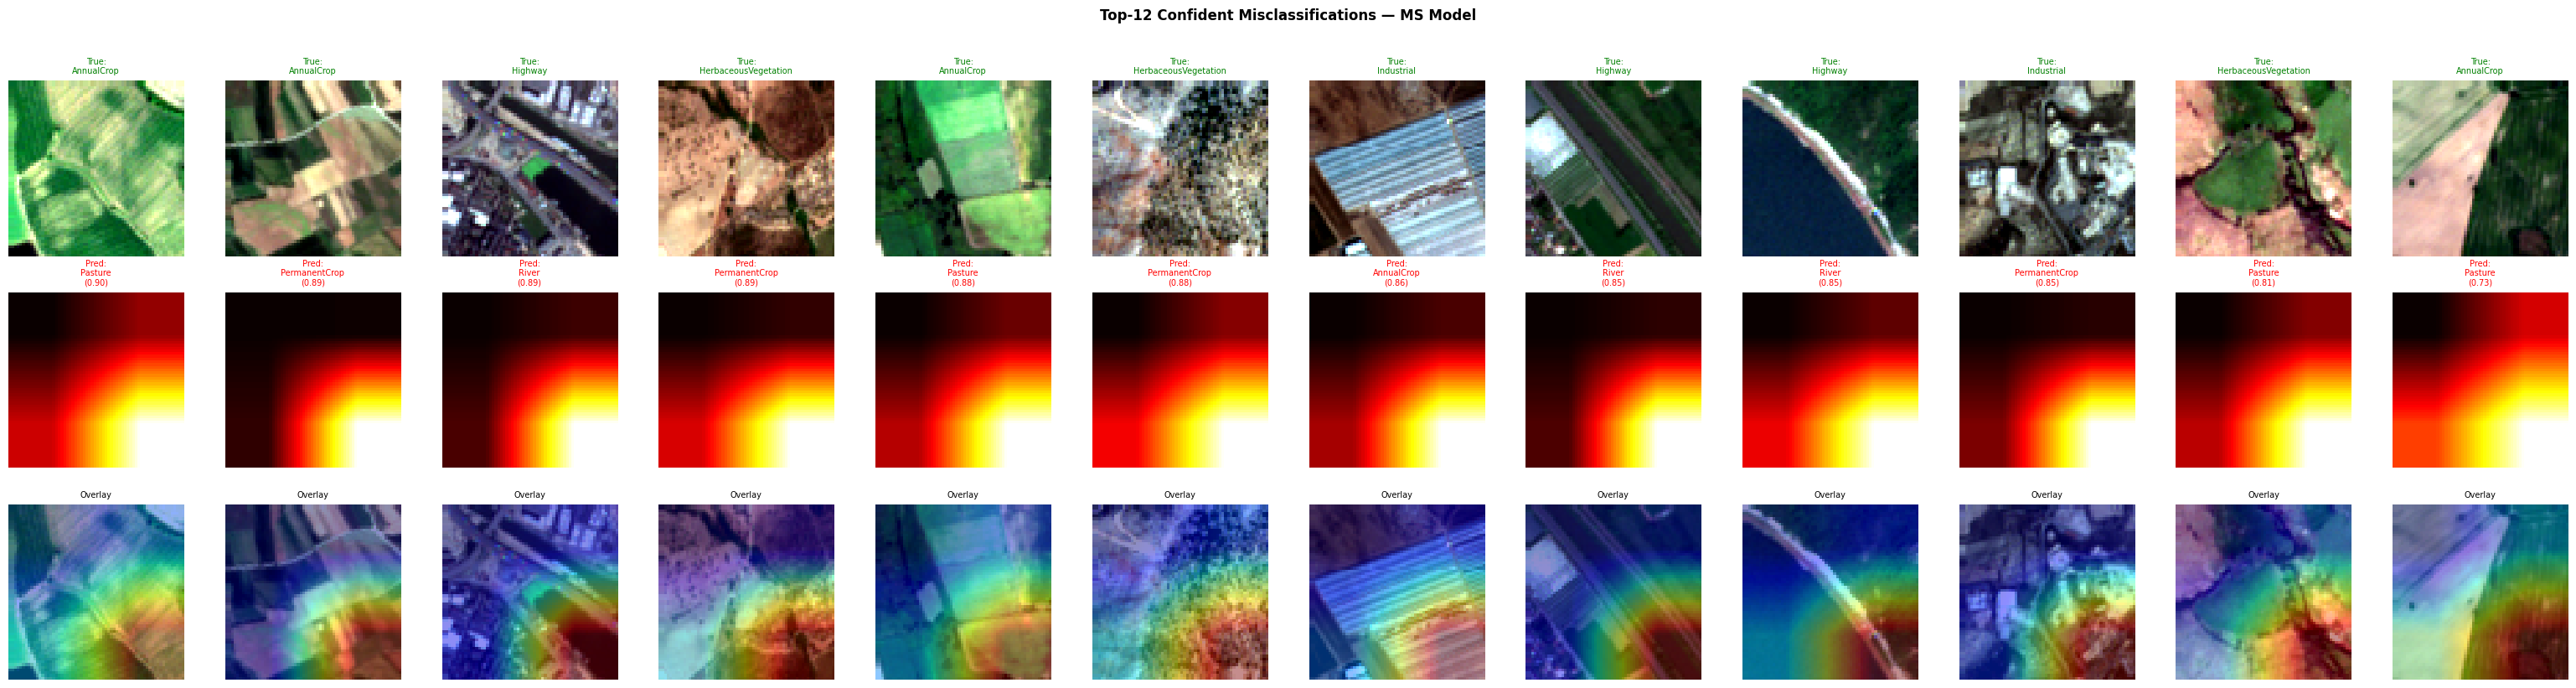


Top confusion pairs (true → predicted):
  AnnualCrop                → Pasture                   : 4 times
  HerbaceousVegetation      → PermanentCrop             : 4 times
  Highway                   → River                     : 3 times
  AnnualCrop                → PermanentCrop             : 2 times
  Industrial                → PermanentCrop             : 2 times
  HerbaceousVegetation      → Pasture                   : 2 times
  Industrial                → AnnualCrop                : 1 times
  AnnualCrop                → HerbaceousVegetation      : 1 times


In [25]:
def find_confident_errors(model, dataset, class_names, device, modality='rgb', n_top=12):
    """Return the top-n highest-confidence misclassifications from the validation set."""
    model.eval()
    errors = []
    cam_engine = GradCAM(model)

    for idx in range(min(2000, len(dataset))):
        img_t, true_lbl = dataset[idx]
        inp = img_t.unsqueeze(0).to(device)
        with torch.no_grad():
            out   = model(inp)
            probs = F.softmax(out, dim=1)[0]
            pred  = out.argmax(1).item()

        if pred != true_lbl:
            conf = probs[pred].item()
            errors.append({'idx': idx, 'img': img_t, 'true': true_lbl,
                           'pred': pred, 'conf': conf, 'probs': probs.cpu().numpy()})

    errors.sort(key=lambda x: x['conf'], reverse=True)
    top = errors[:n_top]

    n = len(top)
    fig, axes = plt.subplots(3, n, figsize=(n * 2.6, 8))
    if n == 1:
        axes = axes.reshape(3, 1)

    for col, e in enumerate(top):
        img_t   = e['img']
        true_l  = class_names[e['true']]
        pred_l  = class_names[e['pred']]
        conf    = e['conf']

        heatmap, _ = cam_engine.generate(img_t, class_idx=e['pred'])

        if modality == 'rgb':
            mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
            std  = np.array(IMAGENET_STD ).reshape(3,1,1)
            rgb  = (img_t[:3].numpy() * std + mean).transpose(1,2,0).clip(0,1)
        else:
            ch = img_t[[3,2,1]].numpy()
            lo, hi = np.percentile(ch, (2,98))
            rgb = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1).transpose(1,2,0)

        axes[0, col].imshow(rgb)
        axes[0, col].set_title(f"True:\n{true_l}", fontsize=7, color='green')
        axes[0, col].axis('off')

        axes[1, col].imshow(heatmap, cmap='hot')
        axes[1, col].set_title(f"Pred:\n{pred_l}\n({conf:.2f})", fontsize=7, color='red')
        axes[1, col].axis('off')

        axes[2, col].imshow(rgb)
        axes[2, col].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[2, col].set_title("Overlay", fontsize=7)
        axes[2, col].axis('off')

    plt.suptitle(f"Top-{n} Confident Misclassifications — {modality.upper()} Model",
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Summarize confusion pairs
    from collections import Counter
    pair_counts = Counter((class_names[e['true']], class_names[e['pred']]) for e in errors[:50])
    print("\nTop confusion pairs (true → predicted):")
    for (true_c, pred_c), cnt in pair_counts.most_common(8):
        print(f"  {true_c:25s} → {pred_c:25s} : {cnt} times")


print("\nAnalyzing RGB model misclassifications...")
find_confident_errors(model_rgb, val_dataset, train_dataset.classes, device, modality='rgb')

print("\nAnalyzing Multispectral model misclassifications...")
find_confident_errors(model_ms, val_dataset_ms, train_dataset_ms.classes, device, modality='ms')

## 16. Task 2 — RGB vs. Multispectral Comparison Summary

A direct comparison of per-class accuracy between the RGB and multispectral models reveals exactly where spectral information provides an advantage over RGB alone — particularly for classes that are visually similar but spectrally distinct.

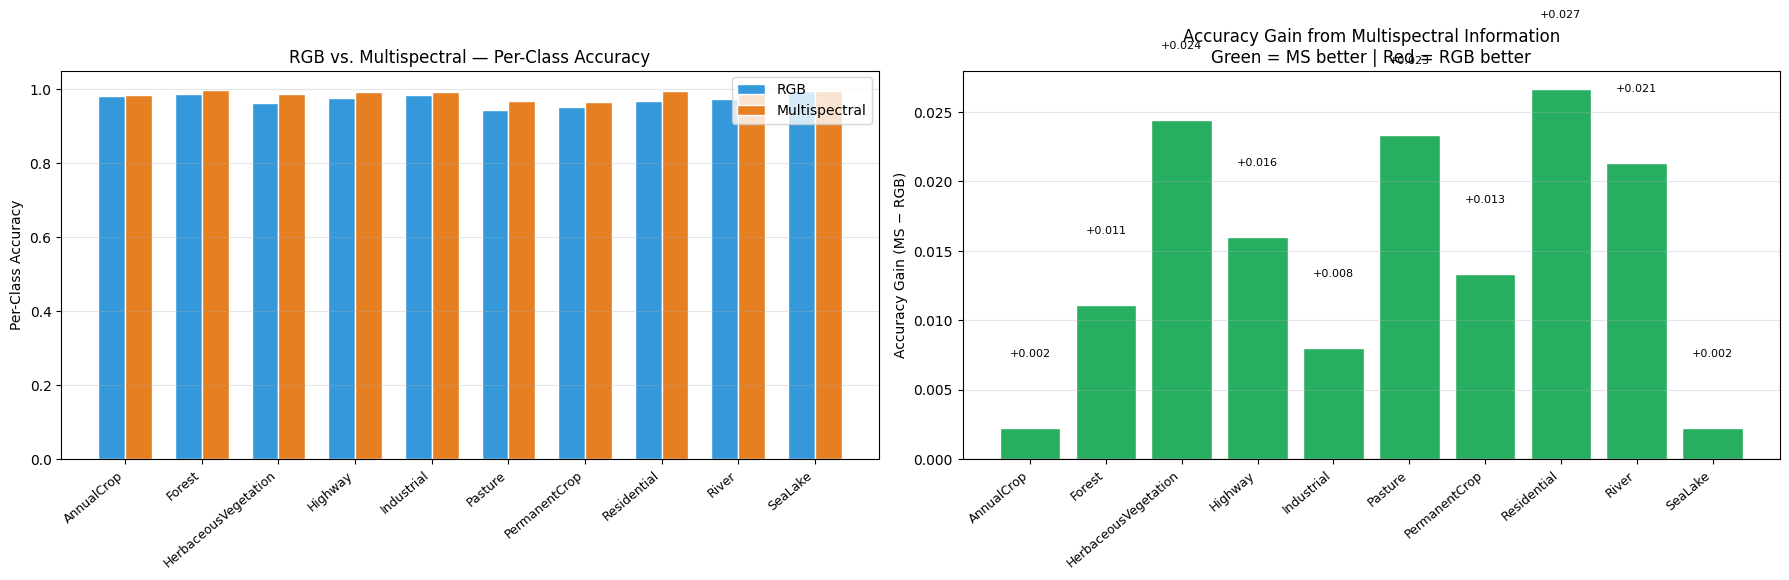


Overall accuracy summary:
  RGB model:           0.9733
  Multispectral model: 0.9879

Classes where multispectral provides largest gain:
  Residential              : +0.0267
  HerbaceousVegetation     : +0.0244
  Pasture                  : +0.0233
  River                    : +0.0213
  Highway                  : +0.0160


In [26]:
def per_class_accuracy(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    return {cls: cm[i,i] / cm[i].sum() if cm[i].sum() > 0 else 0.0
            for i, cls in enumerate(class_names)}

acc_rgb = per_class_accuracy(true_rgb, pred_rgb, train_dataset.classes)
acc_ms  = per_class_accuracy(true_ms,  pred_ms,  train_dataset_ms.classes)

classes = train_dataset.classes
rgb_vals = [acc_rgb[c] for c in classes]
ms_vals  = [acc_ms[c]  for c in classes]
gains    = [m - r for r, m in zip(rgb_vals, ms_vals)]

x = np.arange(len(classes))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Side-by-side bars
axes[0].bar(x - w/2, rgb_vals, w, label='RGB',           color='#3498db', edgecolor='white')
axes[0].bar(x + w/2, ms_vals,  w, label='Multispectral', color='#e67e22', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel("Per-Class Accuracy"); axes[0].set_title("RGB vs. Multispectral — Per-Class Accuracy")
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3); axes[0].set_ylim(0, 1.05)

# Gain plot
colors_gain = ['#27ae60' if g > 0 else '#e74c3c' for g in gains]
axes[1].bar(x, gains, color=colors_gain, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel("Accuracy Gain (MS − RGB)")
axes[1].set_title("Accuracy Gain from Multispectral Information\nGreen = MS better | Red = RGB better")
axes[1].grid(axis='y', alpha=0.3)
for xi, g in zip(x, gains):
    axes[1].text(xi, g + np.sign(g)*0.005, f"{g:+.3f}", ha='center', va='bottom' if g>0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

print("\nOverall accuracy summary:")
print(f"  RGB model:           {sum(t==p for t,p in zip(true_rgb,pred_rgb))/len(true_rgb):.4f}")
print(f"  Multispectral model: {sum(t==p for t,p in zip(true_ms, pred_ms ))/len(true_ms ):.4f}")
print("\nClasses where multispectral provides largest gain:")
for cls, gain in sorted(zip(classes, gains), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {cls:25s}: {gain:+.4f}")

## 17. Task 3 — Bonus: Environmental Insights via Spectral Index Analysis

This section derives actionable environmental and ecological insights from the multispectral data using three well-established remote sensing indices:

| Index | Formula | What it reveals |
|-------|---------|-----------------|
| **NDVI** | (NIR − Red) / (NIR + Red) | Photosynthetically active vegetation density |
| **NDWI** | (Green − NIR) / (Green + NIR) | Open water bodies and surface moisture |
| **NDBI** | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up and urban surfaces |

These indices are computed directly from the raw (un-normalized) Sentinel-2 band values. The analysis shows how each land-use class occupies a distinct region in this three-dimensional spectral index space — a finding with direct relevance to land monitoring, agricultural planning, and urban growth assessment.

In [27]:
SENTINEL2_BAND_ORDER = {
    'B1': 0, 'B2': 1, 'B3': 2, 'B4': 3,
    'B5': 4, 'B6': 5, 'B7': 6, 'B8': 7,
    'B8A': 8, 'B9': 9, 'B10': 10, 'B11': 11, 'B12': 12
}

def compute_spectral_indices(val_dataset_ms, class_names, n_samples=1000):
    """
    Compute NDVI, NDWI, and NDBI for each validation sample.
    Band indices follow the EuroSAT all-bands ordering: B1..B8, B8A, B9..B12.
    """
    rng  = np.random.default_rng(SEED)
    idxs = rng.choice(len(val_dataset_ms), size=min(n_samples, len(val_dataset_ms)), replace=False)

    records = []
    for i in idxs:
        img_t, lbl = val_dataset_ms[int(i)]
        # Re-denormalize to get physically meaningful reflectance values
        raw = img_t * band_std.view(-1,1,1) + band_mean.view(-1,1,1)
        raw = raw.numpy()

        def band(name):
            return raw[SENTINEL2_BAND_ORDER[name]].mean()

        nir   = band('B8')
        red   = band('B4')
        green = band('B3')
        swir1 = band('B11')

        eps = 1e-8
        ndvi = (nir - red)   / (nir + red   + eps)
        ndwi = (green - nir) / (green + nir  + eps)
        ndbi = (swir1 - nir) / (swir1 + nir  + eps)

        records.append({
            'class': class_names[lbl],
            'NDVI': float(ndvi),
            'NDWI': float(ndwi),
            'NDBI': float(ndbi)
        })

    return pd.DataFrame(records)


print("Computing spectral indices from validation set...")
df_indices = compute_spectral_indices(val_dataset_ms, train_dataset_ms.classes, n_samples=1000)
print(f"Computed indices for {len(df_indices)} samples.")
print(df_indices.groupby('class')[['NDVI','NDWI','NDBI']].mean().round(4).to_string())

Computing spectral indices from validation set...
Computed indices for 1000 samples.
                        NDVI    NDWI    NDBI
class                                       
AnnualCrop            0.3713 -0.4062 -0.2956
Forest                0.7199 -0.5775 -0.6644
HerbaceousVegetation  0.3922 -0.3806 -0.2456
Highway               0.4416 -0.4034 -0.3471
Industrial            0.2308 -0.2183 -0.2017
Pasture               0.6689 -0.5543 -0.5726
PermanentCrop         0.3610 -0.3795 -0.2287
Residential           0.3465 -0.3203 -0.2367
River                 0.4302 -0.3153 -0.4593
SeaLake              -0.2197  0.4311 -0.7342


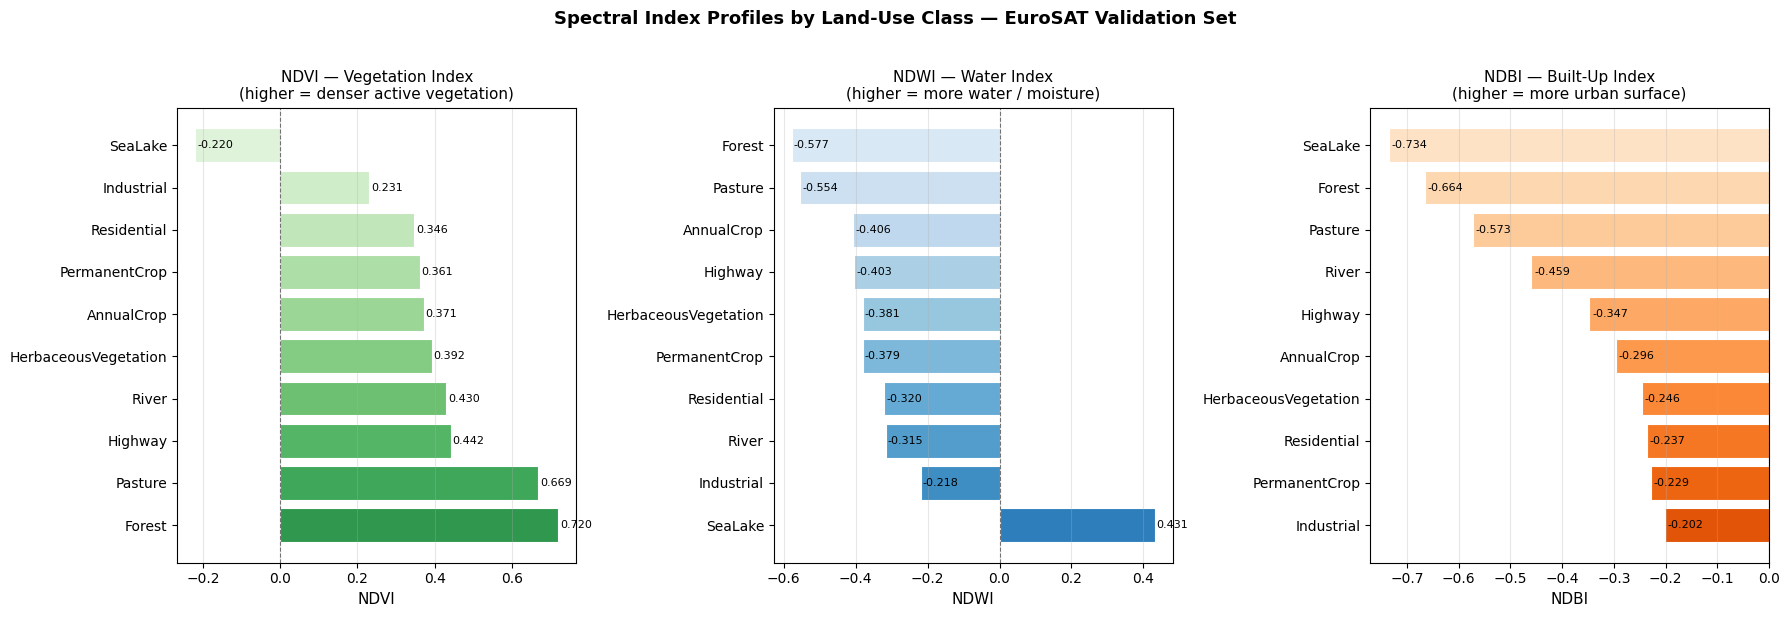

In [28]:
# Visualize spectral index distributions by class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
indices = ['NDVI', 'NDWI', 'NDBI']
palettes = ['Greens_r', 'Blues_r', 'Oranges_r']
titles = [
    'NDVI — Vegetation Index\n(higher = denser active vegetation)',
    'NDWI — Water Index\n(higher = more water / moisture)',
    'NDBI — Built-Up Index\n(higher = more urban surface)'
]

for ax, idx_name, palette, title in zip(axes, indices, palettes, titles):
    order = df_indices.groupby('class')[idx_name].mean().sort_values(ascending=False).index.tolist()
    means = df_indices.groupby('class')[idx_name].mean().loc[order]
    colors = plt.get_cmap(palette)(np.linspace(0.3, 0.85, len(order)))

    bars = ax.barh(order, means, color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(idx_name, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, means):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va='center', fontsize=8)

plt.suptitle("Spectral Index Profiles by Land-Use Class — EuroSAT Validation Set",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

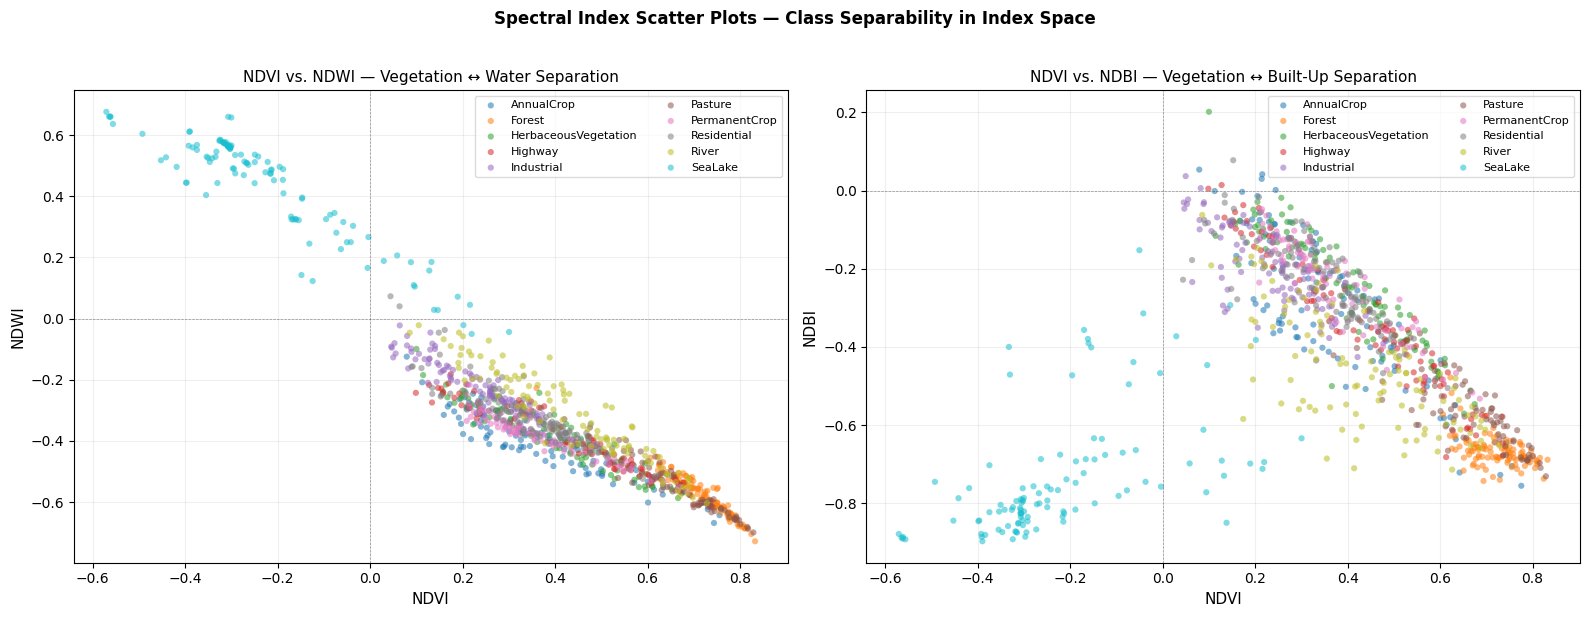

In [29]:
# NDVI vs. NDWI scatter — reveals natural spectral clustering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_tab10 = plt.get_cmap('tab10')
class_list = train_dataset_ms.classes

for ax, (x_col, y_col, title) in zip(axes, [
    ('NDVI', 'NDWI', 'NDVI vs. NDWI — Vegetation ↔ Water Separation'),
    ('NDVI', 'NDBI', 'NDVI vs. NDBI — Vegetation ↔ Built-Up Separation')
]):
    for k, cls in enumerate(class_list):
        sub = df_indices[df_indices['class'] == cls]
        ax.scatter(sub[x_col], sub[y_col], label=cls, alpha=0.55, s=20,
                   color=cmap_tab10(k), edgecolors='none')

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.set_xlabel(x_col, fontsize=11); ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='best', ncol=2, framealpha=0.7)

plt.suptitle("Spectral Index Scatter Plots — Class Separability in Index Space",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

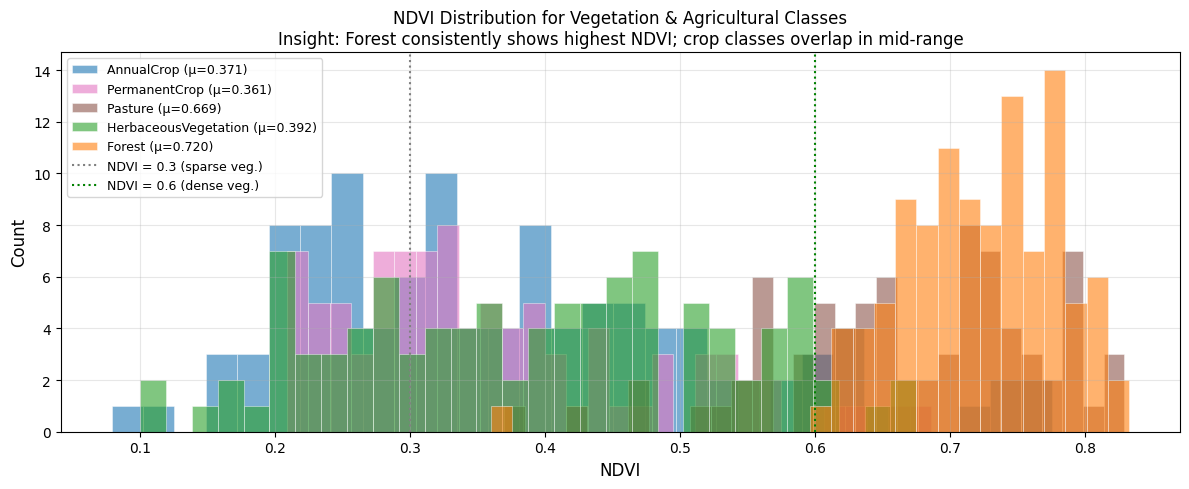


Vegetation health summary (NDVI statistics):
                        mean     std     min     max
class                                               
AnnualCrop            0.3713  0.1524  0.0793  0.7755
Forest                0.7199  0.0648  0.3599  0.8324
HerbaceousVegetation  0.3922  0.1397  0.1003  0.6748
Pasture               0.6689  0.0968  0.3696  0.8288
PermanentCrop         0.3610  0.1128  0.2089  0.6858


In [30]:
# NDVI health analysis for agricultural and vegetation classes
agri_classes = ['AnnualCrop', 'PermanentCrop', 'Pasture', 'HerbaceousVegetation', 'Forest']

fig, ax = plt.subplots(figsize=(12, 5))
cmap_tab10 = plt.get_cmap('tab10')
for k, cls in enumerate(agri_classes):
    sub = df_indices[df_indices['class'] == cls]['NDVI']
    color = cmap_tab10(list(class_list).index(cls))
    ax.hist(sub, bins=30, alpha=0.6, label=f"{cls} (μ={sub.mean():.3f})",
            color=color, edgecolor='white', linewidth=0.5)

ax.axvline(0.3, color='gray',  linestyle=':', linewidth=1.5, label='NDVI = 0.3 (sparse veg.)')
ax.axvline(0.6, color='green', linestyle=':', linewidth=1.5, label='NDVI = 0.6 (dense veg.)')
ax.set_xlabel("NDVI", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("NDVI Distribution for Vegetation & Agricultural Classes\n"
             "Insight: Forest consistently shows highest NDVI; crop classes overlap in mid-range",
             fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVegetation health summary (NDVI statistics):")
print(df_indices[df_indices['class'].isin(agri_classes)]
      .groupby('class')['NDVI']
      .describe()[['mean','std','min','max']].round(4).to_string())

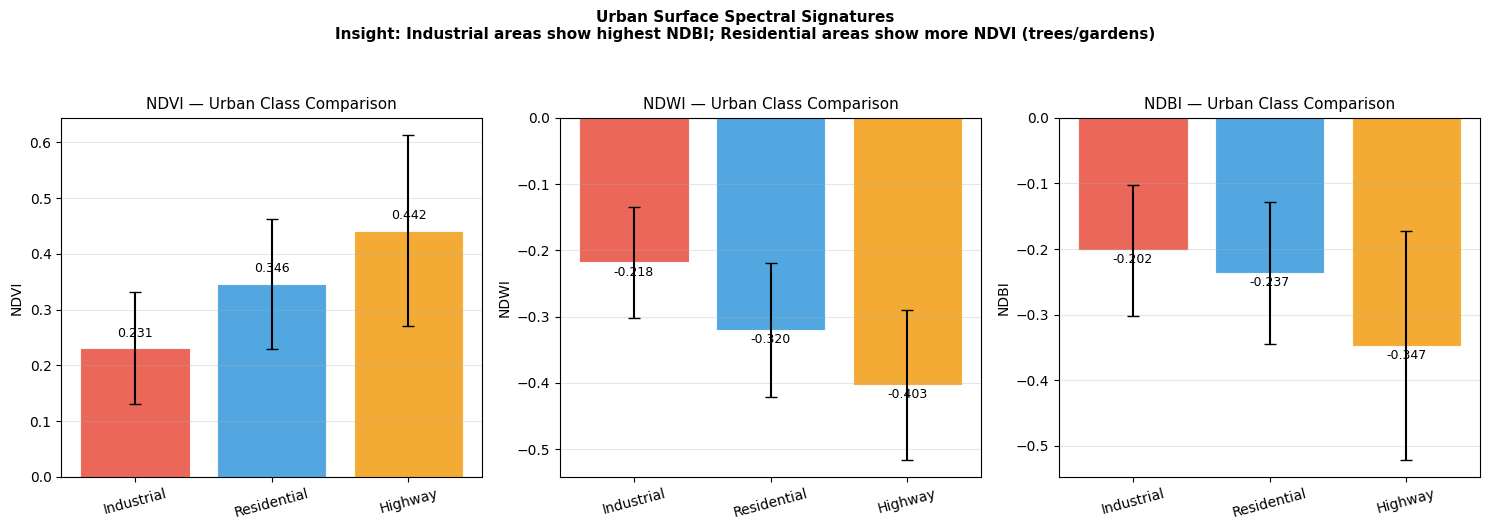

In [31]:
# Urban vs. industrial vs. residential spectral signature comparison
urban_classes = ['Industrial', 'Residential', 'Highway']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['NDVI', 'NDWI', 'NDBI']
colors_urban = ['#e74c3c', '#3498db', '#f39c12']

for ax, metric in zip(axes, metrics):
    means = [df_indices[df_indices['class'] == cls][metric].mean() for cls in urban_classes]
    stds  = [df_indices[df_indices['class'] == cls][metric].std()  for cls in urban_classes]
    bars = ax.bar(urban_classes, means, yerr=stds, color=colors_urban,
                  capsize=4, edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(f"{metric} — Urban Class Comparison", fontsize=11)
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, val + np.sign(val)*0.02,
                f"{val:.3f}", ha='center', fontsize=9)

plt.suptitle("Urban Surface Spectral Signatures\n"
             "Insight: Industrial areas show highest NDBI; Residential areas show more NDVI (trees/gardens)",
             fontsize=11, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 18. Final Summary

In [32]:
print("=" * 65)
print("  GEO SNAP — PIXELPIONEERS — FINAL RESULTS SUMMARY")
print("=" * 65)

acc_rgb_overall = sum(t==p for t,p in zip(true_rgb,pred_rgb)) / len(true_rgb)
acc_ms_overall  = sum(t==p for t,p in zip(true_ms, pred_ms )) / len(true_ms )

print(f"\nTask 1A — RGB Classification (EfficientNet-B2)")
print(f"  Validation Accuracy : {acc_rgb_overall:.4f}  ({acc_rgb_overall*100:.2f}%)")

print(f"\nTask 1B — Multispectral Classification (EfficientNet-B2, 13-band)")
print(f"  Validation Accuracy : {acc_ms_overall:.4f}  ({acc_ms_overall*100:.2f}%)")

print(f"\nTask 2 — Explainability & Model Interpretation")
print(f"  2A Visual: Grad-CAM grids (correct + incorrect predictions)")
print(f"  2B Spectral: Band occlusion importance + per-class spectral profiles")
print(f"  2C Error: Confusion matrices, per-class accuracy, top misclassifications")

print(f"\nTask 3 — Bonus Environmental Insights")
print(f"  NDVI analysis: vegetation health & crop discrimination")
print(f"  NDWI analysis: water body & moisture mapping")
print(f"  NDBI analysis: urban surface signatures")
print(f"  Scatter analysis: spectral index separability by class")

print(f"\nDeliverables")
print(f"  rgb_predictions.csv         — Task 1A test set predictions")
print(f"  ms_predictions.csv          — Task 1B test set predictions")
print(f"  rgb_predictions_proba.csv   — Task 1A with class probabilities")
print(f"  ms_predictions_proba.csv    — Task 1B with class probabilities")
print(f"  efficientnet_b2_rgb_final.pth")
print(f"  efficientnet_b2_ms_final.pth")
print("=" * 65)

  GEO SNAP — PIXELPIONEERS — FINAL RESULTS SUMMARY

Task 1A — RGB Classification (EfficientNet-B2)
  Validation Accuracy : 0.9733  (97.33%)

Task 1B — Multispectral Classification (EfficientNet-B2, 13-band)
  Validation Accuracy : 0.9879  (98.79%)

Task 2 — Explainability & Model Interpretation
  2A Visual: Grad-CAM grids (correct + incorrect predictions)
  2B Spectral: Band occlusion importance + per-class spectral profiles
  2C Error: Confusion matrices, per-class accuracy, top misclassifications

Task 3 — Bonus Environmental Insights
  NDVI analysis: vegetation health & crop discrimination
  NDWI analysis: water body & moisture mapping
  NDBI analysis: urban surface signatures
  Scatter analysis: spectral index separability by class

Deliverables
  rgb_predictions.csv         — Task 1A test set predictions
  ms_predictions.csv          — Task 1B test set predictions
  rgb_predictions_proba.csv   — Task 1A with class probabilities
  ms_predictions_proba.csv    — Task 1B with class pr